In [ ]:
#################################
# changes from previous version
#################################

# v13 changes:
# 1. starts from a clean v14 run by default and does not reuse leftover v13 checkpoints
# 2. writes generator checkpoints into a dedicated `checkpoints_V14` folder inside the v13 Drive run directory
# 3. keeps the disconnect-safe checkpointing and Drive snapshot behavior from v12
# 4. keeps the capped cached lexicon workflow for faster reranker features
# 5. expands Arabizi-aware augmentation and token handling for better robustness
# 6. strengthens the learned reranker with richer inference-time features
# 7. trains rerankers for both directions by default

# v14 refresh: saves all run artifacts under MyDrive/arabizi and adds beam-search hit-rate/MRR/rank metrics to generated evaluation summaries and the rolling performance CSV.


In [ ]:
#################################
# installs (uncomment in a fresh Colab runtime if needed)
#################################

#!pip install -q pandas scikit-learn matplotlib tqdm ipywidgets


In [ ]:
#################################
# imports
#################################

import math
import json
import copy
import random
import re
import unicodedata
import os
import shutil
import urllib.request
import zipfile
from collections import Counter, defaultdict
from pathlib import Path
from datetime import datetime
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

try:
    from google.colab import drive, output
    IN_COLAB = True
except Exception:
    drive = None
    output = None
    IN_COLAB = False


In [ ]:
#################################
# connect to google drive (optional in Colab)
#################################

if IN_COLAB:
    drive.mount('/content/drive')
else:
    print('Not running inside Colab. Skipping Google Drive mount.')


Mounted at /content/drive


In [ ]:
#################################
# user-manipulable variables summary
# define all user-editable variables here
#################################

# ---------------------------
# data location and columns
# ---------------------------
DATA_ROOT = Path("/content/drive/MyDrive/arabizi")

# Try the common Maknuune filenames under the new arabizi Drive folder.
def resolve_maknune_data_path():
    candidates = [
        DATA_ROOT / "maknuune-v1.0.1_cleaned.tsv",
        DATA_ROOT / "maknuune-v1.0.1" / "maknuune-v1.0.1_cleaned.tsv",
        DATA_ROOT / "maknuune-v1.0.1" / "maknuune-v1.0.1" / "maknuune-v1.0.1_cleaned.tsv",
        DATA_ROOT / "maknuune_cleaned.tsv",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]

data_path = resolve_maknune_data_path()
arabic_col = "FORM_CLEAN"
arabizi_col = "CAPHI++_CLEAN"

# ---------------------------
# experiment naming
# ---------------------------
EXPERIMENT_NAME = "arabizi_arabic_transformer_best_v14"

# v14 settings for a fresh run on the new Drive folder
# this notebook now trains from scratch in the current run directory and does not
# try to seed itself from any earlier experiment checkpoints.
USE_PREVIOUS_EXPERIMENT_CHECKPOINTS = False
PREVIOUS_EXPERIMENT_NAME = ""
COPY_PREVIOUS_CHECKPOINTS_INTO_CURRENT_RUN = False
SKIP_BASE_TRAINING_WHEN_PREVIOUS_CHECKPOINT_AVAILABLE = False

# set this True so the v14 run folder starts clean before training from scratch checkpoints.
START_FRESH_V14_RUN = False

# ---------------------------
# training strategy
# options:
#   "separate" = one model per direction (default and recommended)
#   "shared"   = one shared bidirectional model with direction tokens
# ---------------------------
TRAINING_STRATEGY = "separate"

# used only when TRAINING_STRATEGY == "shared"
TO_ARABIC = ""
TO_ARABIZI = ""

# ---------------------------
# reproducibility and splits
# ---------------------------
SEED = 42
VAL_SIZE = 0.10
TEST_SIZE = 0.10

# ---------------------------
# dataloader
# Colab/notebook-safe defaults
# ---------------------------
BATCH_SIZE = 96
NUM_WORKERS = 0
PIN_MEMORY = NUM_WORKERS > 0
PERSISTENT_WORKERS = False

# ---------------------------
# optimization
# ---------------------------
NUM_EPOCHS = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.02
GRAD_CLIP_NORM = 1.0

# scheduler
USE_LR_SCHEDULER = True
LR_SCHEDULER_TYPE = "cosine"      # "cosine" or "plateau"
WARMUP_EPOCHS = 5
MIN_LR = 1e-5
LR_SCHEDULER_FACTOR = 0.5         # only for plateau
LR_SCHEDULER_PATIENCE = 2         # only for plateau

# early stopping
EARLY_STOPPING_PATIENCE = 16

# ---------------------------
# optional curriculum warm start
# v9 lets the model spend a bit longer on shorter targets first
# ---------------------------
USE_LENGTH_CURRICULUM = True
CURRICULUM_MAX_TARGET_LEN = 16
CURRICULUM_EPOCHS = 8

# ---------------------------
# model architecture
# use the v12 base architecture while keeping the rest of the v14 training/eval pipeline
# ---------------------------
D_MODEL = 256
NHEAD = 8
NUM_ENCODER_LAYERS = 4
NUM_DECODER_LAYERS = 4
DIM_FEEDFORWARD = 1024
DROPOUT = 0.15

# ---------------------------
# sequence / vocabulary
# ---------------------------
MAX_LEN_QUANTILE = 0.9995
MIN_COUNT_PER_TOKEN = 1

# ---------------------------
# long-sequence emphasis
# v9 pushes a little harder on longer targets because they were still underperforming
# ---------------------------
USE_WEIGHTED_SAMPLER = True
LONG_TARGET_LEN_THRESHOLD = 10
VERY_LONG_TARGET_LEN_THRESHOLD = 14
EXTREME_TARGET_LEN_THRESHOLD = 20

LONG_SEQUENCE_WEIGHT = 2.0
VERY_LONG_SEQUENCE_WEIGHT = 3.0
EXTREME_SEQUENCE_WEIGHT = 4.0

# extra emphasis for the harder direction in shared mode
# this also affects separate-task sample weighting logic in the notebook
ARABIZI_TO_ARABIC_WEIGHT = 1.4

# ---------------------------
# Arabizi-aware tokenization
# longest patterns should come first
# ---------------------------
ARABIZI_MULTI_TOKENS = [
    "sch", "tsh",
    "sh", "kh", "gh", "th", "dh", "ch", "ph", "zh",
    "2'", "3'", "5'", "6'", "7'", "8'", "9'",
    "7a", "7o", "7e", "3a", "3o", "3e", "2a", "2i", "2o",
    "5a", "5o", "5e", "6a", "6o", "6e", "8a", "8o", "8e", "9a", "9o", "9e",
    "aa", "ii", "uu", "oo", "ee",
    "ou", "aw", "ay"
]

ARABIZI_DIGITS = list("23456789")

# ---------------------------
# text normalization
# ---------------------------
NORMALIZE_UNICODE_FORM = "NFC"
LOWERCASE_ARABIZI = True
COLLAPSE_EXTRA_WHITESPACE = True
STRIP_TEXT = True

# Arabic normalization toggles
STRIP_ARABIC_TATWEEL = True
NORMALIZE_ARABIC_ALEF_VARIANTS = True
NORMALIZE_ARABIC_YAA_VARIANTS = True
NORMALIZE_ARABIC_TAA_MARBUTA = False

# Arabizi normalization toggles
NORMALIZE_ARABIZI_APOSTROPHES = True
COLLAPSE_ARABIZI_CHAR_REPEATS_IN_NORMALIZATION = True
MAX_CONSECUTIVE_ARABIZI_REPEATS = 2

# ---------------------------
# optional ambiguity handling
# keep the most frequent target per source to reduce supervision noise
# ---------------------------
SHOW_AMBIGUITY_AUDIT = True
KEEP_ONLY_MOST_FREQUENT_TARGET_PER_SOURCE = True
MOST_FREQUENT_TIE_BREAK = "shortest_target"   # "shortest_target" or "first_seen"

# ---------------------------
# augmentation for Arabizi source text
# keep augmentation modest so it helps robustness without adding much noise
# ---------------------------
ENABLE_ARABIZI_AUGMENTATION = True
AUGMENTATION_DUPLICATES = 3
AUGMENT_PROB_VOWEL_LENGTH = 0.20
AUGMENT_PROB_REPEAT_NORMALIZATION = 0.20
AUGMENT_PROB_DIGIT_VARIATION = 0.15
AUGMENT_PROB_WHITESPACE_CLEANUP = 0.15
AUGMENT_PROB_DIGRAPH_VARIATION = 0.15
AUGMENT_PROB_APOSTROPHE_NORMALIZATION = 0.12
AUGMENT_PROB_VOWEL_DROP = 0.10

# ---------------------------
# inference
# v12 widens search a bit more so reranking has a stronger candidate pool
# ---------------------------
DEFAULT_DECODER = "beam"          # "greedy" or "beam"
BEAM_SIZE = 20
BEAM_LENGTH_PENALTY = 0.80
TOP_K_EVAL_K = 12
BEAM_METRIC_KS = [1, 3, 5, 10]
RETURN_TOP_K_PREDICTIONS = 12

# ---------------------------
# evaluation
# set to None to evaluate the full generated validation/test sets
# ---------------------------
MAX_FULL_GENERATION_EVAL_ROWS = None
LENGTH_BUCKETS = [(1, 5), (6, 10), (11, 15), (16, 20), (21, 1000)]

# Arabizi -> Arabic practical evaluation strips Arabic diacritics
STRIP_DIACRITICS_FOR_ARABIZI_TO_ARABIC_EVAL = True

# Arabic -> Arabizi evaluation keeps digits and can lowercase for fair matching
LOWERCASE_ARABIZI_FOR_EVAL = LOWERCASE_ARABIZI

# optional lexicon-aware reranking for Arabizi -> Arabic top-k outputs
# this v9 variant uses the external Arabic Wordlist for Spellchecking by default
# the SourceForge project says this word list is generated from AraComLex
USE_ARABIC_LEXICON_RERANKING = False
ARABIC_LEXICON_SOURCE = "arabic_wordlist"   # "arabic_wordlist", "aracomlex", "train_only", or "all_targets"
PREFER_LEXICON_MATCH_IN_TOP_K = False

# external lexicon download / extraction settings
# the Arabic Wordlist project page says this list contains about 9 million Arabic words,
# is automatically generated from AraComLex, and was validated against Microsoft Word spell checker
ARABIC_WORDLIST_DOWNLOAD_URL = "https://sourceforge.net/projects/arabic-wordlist/files/Arabic-Wordlist-1.5.zip/download"
ARABIC_WORDLIST_ZIP_PATH = Path("/content/Arabic-Wordlist-1.5.zip") if IN_COLAB else Path("Arabic-Wordlist-1.5.zip")
ARABIC_WORDLIST_EXTRACT_DIR = Path("/content/arabic_wordlist_v1_5") if IN_COLAB else Path("arabic_wordlist_v1_5")
ARABIC_WORDLIST_FORCE_REDOWNLOAD = False
ARABIC_WORDLIST_ALLOW_FALLBACK_TO_INTERNAL = True
ARABIC_WORDLIST_MIN_TOKEN_LEN = 2

# legacy AraComLex direct-download settings are kept available in case you want to compare sources later
ARACOMLEX_DOWNLOAD_URL = "https://sourceforge.net/projects/aracomlex/files/AraComLex%20v2.0/AraComLex2.0.zip/download"
ARACOMLEX_ZIP_PATH = Path("/content/AraComLex2.0.zip") if IN_COLAB else Path("AraComLex2.0.zip")
ARACOMLEX_EXTRACT_DIR = Path("/content/aracomlex_v2") if IN_COLAB else Path("aracomlex_v2")
ARACOMLEX_FORCE_REDOWNLOAD = False
ARACOMLEX_ALLOW_FALLBACK_TO_INTERNAL = True
ARACOMLEX_MIN_TOKEN_LEN = 2

# soft lexicon reranking
USE_SOFT_LEXICON_RERANKING = True
SOFT_LEXICON_BONUS = 0.20
MAX_LEXICON_SCORE_GAP = 1.25


# ---------------------------
# learned candidate reranker
# v10 keeps the seq2seq model as the generator and learns a small scorer
# over beam candidates instead of relying only on a hand-written lexicon bonus
# ---------------------------
USE_LEARNED_CANDIDATE_RERANKER = True
LEARNED_RERANKER_DIRECTIONS = ["arabizi_to_arabic", "arabic_to_arabizi"]
RERANKER_TOP_K = BEAM_SIZE
# keep reranker candidate generation aligned with the beam width used at inference
RERANKER_TRAIN_MAX_ROWS = 5000
RERANKER_VAL_MAX_ROWS = 1000
RERANKER_HIDDEN_DIM = 128
RERANKER_BATCH_SIZE = 256
RERANKER_EPOCHS = 12
RERANKER_LEARNING_RATE = 1e-3
RERANKER_WEIGHT_DECAY = 1e-5
RERANKER_PATIENCE = 3
RERANKER_LABEL_POSITIVE_MODE = "practical_exact"   # "strict_exact" or "practical_exact"
RERANKER_FEATURE_USE_ARABIC_LEXICON = True
RERANKER_FEATURE_USE_ARABIZI_LEXICON = True
RERANKER_MIN_POSITIVES_WARN = 100
RERANKER_APPLY_DURING_INFERENCE = True
RERANKER_FALLBACK_TO_BASE_ORDER = True


# ---------------------------
# disconnect-safe saving and resume
# ---------------------------
ENABLE_PERSISTENT_SAVES = True
RESUME_FROM_LATEST_CHECKPOINT = True
SAVE_LATEST_CHECKPOINT_EVERY_EPOCH = True
SAVE_BEST_CHECKPOINT = True
EXPORT_WEBSITE_ARTIFACTS = True

if IN_COLAB:
    DRIVE_RUNS_ROOT = Path("/content/drive/MyDrive/arabizi")
else:
    DRIVE_RUNS_ROOT = Path.cwd() / "arabizi_runs"

# every long stage writes into this experiment-specific folder on Drive
RUN_OUTPUT_DIR = DRIVE_RUNS_ROOT / EXPERIMENT_NAME
# keep checkpoints in their own dedicated folder inside the v14 run directory
CHECKPOINT_DIR = RUN_OUTPUT_DIR / "checkpoints_V14"
LATEST_CHECKPOINT_DIR = CHECKPOINT_DIR / "latest"
BEST_CHECKPOINT_DIR = CHECKPOINT_DIR / "best"
WEBSITE_EXPORT_DIR = RUN_OUTPUT_DIR / "website_exports"
STATE_DIR = RUN_OUTPUT_DIR / "state"
TABLE_DIR = RUN_OUTPUT_DIR / "tables"
LOG_DIR = RUN_OUTPUT_DIR / "logs"

LEXICON_CACHE_DIR = DRIVE_RUNS_ROOT / "_shared_lexicon_cache"
LATEST_PERFORMANCE_CSV_PATH = RUN_OUTPUT_DIR / "latest_model_performance.csv"
ARABIC_LEXICON_CACHE_PATH = LEXICON_CACHE_DIR / "known_arabic_words_cap_50000.pkl"
ARABIZI_LEXICON_CACHE_PATH = LEXICON_CACHE_DIR / "known_arabizi_words_cap_50000.pkl"
LEXICON_CACHE_METADATA_PATH = LEXICON_CACHE_DIR / "lexicon_cache_metadata_cap_50000.json"

# ---------------------------
# demo-friendly cached lexicon settings
# these settings trade some lexicon coverage for much faster reranker/evaluation setup
# the Arabic external wordlist is not frequency-ranked, so we use a hard cap instead of "top x%"
# ---------------------------
USE_DRIVE_CACHED_LEXICONS = True
FORCE_REBUILD_DRIVE_CACHED_LEXICONS = False
MAX_KNOWN_ARABIC_WORDS = 50000
MAX_KNOWN_ARABIZI_WORDS = 50000


# ---------------------------
# device
# ---------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# seeds
# ---------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

user_config = {
    "data_path": str(data_path),
    "arabic_col": arabic_col,
    "arabizi_col": arabizi_col,
    "EXPERIMENT_NAME": EXPERIMENT_NAME,
    "TRAINING_STRATEGY": TRAINING_STRATEGY,
    "TO_ARABIC": repr(TO_ARABIC),
    "TO_ARABIZI": repr(TO_ARABIZI),
    "SEED": SEED,
    "VAL_SIZE": VAL_SIZE,
    "TEST_SIZE": TEST_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_WORKERS": NUM_WORKERS,
    "PIN_MEMORY": PIN_MEMORY,
    "PERSISTENT_WORKERS": PERSISTENT_WORKERS,
    "NUM_EPOCHS": NUM_EPOCHS,
    "LEARNING_RATE": LEARNING_RATE,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "LABEL_SMOOTHING": LABEL_SMOOTHING,
    "GRAD_CLIP_NORM": GRAD_CLIP_NORM,
    "USE_LR_SCHEDULER": USE_LR_SCHEDULER,
    "LR_SCHEDULER_TYPE": LR_SCHEDULER_TYPE,
    "WARMUP_EPOCHS": WARMUP_EPOCHS,
    "MIN_LR": MIN_LR,
    "LR_SCHEDULER_FACTOR": LR_SCHEDULER_FACTOR,
    "LR_SCHEDULER_PATIENCE": LR_SCHEDULER_PATIENCE,
    "EARLY_STOPPING_PATIENCE": EARLY_STOPPING_PATIENCE,
    "USE_LENGTH_CURRICULUM": USE_LENGTH_CURRICULUM,
    "CURRICULUM_MAX_TARGET_LEN": CURRICULUM_MAX_TARGET_LEN,
    "CURRICULUM_EPOCHS": CURRICULUM_EPOCHS,
    "D_MODEL": D_MODEL,
    "NHEAD": NHEAD,
    "NUM_ENCODER_LAYERS": NUM_ENCODER_LAYERS,
    "NUM_DECODER_LAYERS": NUM_DECODER_LAYERS,
    "DIM_FEEDFORWARD": DIM_FEEDFORWARD,
    "DROPOUT": DROPOUT,
    "MAX_LEN_QUANTILE": MAX_LEN_QUANTILE,
    "MIN_COUNT_PER_TOKEN": MIN_COUNT_PER_TOKEN,
    "USE_WEIGHTED_SAMPLER": USE_WEIGHTED_SAMPLER,
    "LONG_TARGET_LEN_THRESHOLD": LONG_TARGET_LEN_THRESHOLD,
    "VERY_LONG_TARGET_LEN_THRESHOLD": VERY_LONG_TARGET_LEN_THRESHOLD,
    "EXTREME_TARGET_LEN_THRESHOLD": EXTREME_TARGET_LEN_THRESHOLD,
    "LONG_SEQUENCE_WEIGHT": LONG_SEQUENCE_WEIGHT,
    "VERY_LONG_SEQUENCE_WEIGHT": VERY_LONG_SEQUENCE_WEIGHT,
    "EXTREME_SEQUENCE_WEIGHT": EXTREME_SEQUENCE_WEIGHT,
    "ARABIZI_TO_ARABIC_WEIGHT": ARABIZI_TO_ARABIC_WEIGHT,
    "ARABIZI_MULTI_TOKENS": ARABIZI_MULTI_TOKENS,
    "ARABIZI_DIGITS": ARABIZI_DIGITS,
    "NORMALIZE_UNICODE_FORM": NORMALIZE_UNICODE_FORM,
    "LOWERCASE_ARABIZI": LOWERCASE_ARABIZI,
    "COLLAPSE_EXTRA_WHITESPACE": COLLAPSE_EXTRA_WHITESPACE,
    "STRIP_TEXT": STRIP_TEXT,
    "SHOW_AMBIGUITY_AUDIT": SHOW_AMBIGUITY_AUDIT,
    "KEEP_ONLY_MOST_FREQUENT_TARGET_PER_SOURCE": KEEP_ONLY_MOST_FREQUENT_TARGET_PER_SOURCE,
    "MOST_FREQUENT_TIE_BREAK": MOST_FREQUENT_TIE_BREAK,
    "ENABLE_ARABIZI_AUGMENTATION": ENABLE_ARABIZI_AUGMENTATION,
    "AUGMENTATION_DUPLICATES": AUGMENTATION_DUPLICATES,
    "AUGMENT_PROB_VOWEL_LENGTH": AUGMENT_PROB_VOWEL_LENGTH,
    "AUGMENT_PROB_REPEAT_NORMALIZATION": AUGMENT_PROB_REPEAT_NORMALIZATION,
    "AUGMENT_PROB_DIGIT_VARIATION": AUGMENT_PROB_DIGIT_VARIATION,
    "AUGMENT_PROB_WHITESPACE_CLEANUP": AUGMENT_PROB_WHITESPACE_CLEANUP,
    "DEFAULT_DECODER": DEFAULT_DECODER,
    "BEAM_SIZE": BEAM_SIZE,
    "BEAM_LENGTH_PENALTY": BEAM_LENGTH_PENALTY,
    "TOP_K_EVAL_K": TOP_K_EVAL_K,
    "RETURN_TOP_K_PREDICTIONS": RETURN_TOP_K_PREDICTIONS,
    "STRIP_DIACRITICS_FOR_ARABIZI_TO_ARABIC_EVAL": STRIP_DIACRITICS_FOR_ARABIZI_TO_ARABIC_EVAL,
    "LOWERCASE_ARABIZI_FOR_EVAL": LOWERCASE_ARABIZI_FOR_EVAL,
    "USE_ARABIC_LEXICON_RERANKING": USE_ARABIC_LEXICON_RERANKING,
    "ARABIC_LEXICON_SOURCE": ARABIC_LEXICON_SOURCE,
    "PREFER_LEXICON_MATCH_IN_TOP_K": PREFER_LEXICON_MATCH_IN_TOP_K,
    "ARABIC_WORDLIST_DOWNLOAD_URL": ARABIC_WORDLIST_DOWNLOAD_URL,
    "ARABIC_WORDLIST_ZIP_PATH": str(ARABIC_WORDLIST_ZIP_PATH),
    "ARABIC_WORDLIST_EXTRACT_DIR": str(ARABIC_WORDLIST_EXTRACT_DIR),
    "ARABIC_WORDLIST_FORCE_REDOWNLOAD": ARABIC_WORDLIST_FORCE_REDOWNLOAD,
    "ARABIC_WORDLIST_ALLOW_FALLBACK_TO_INTERNAL": ARABIC_WORDLIST_ALLOW_FALLBACK_TO_INTERNAL,
    "ARABIC_WORDLIST_MIN_TOKEN_LEN": ARABIC_WORDLIST_MIN_TOKEN_LEN,
    "USE_DRIVE_CACHED_LEXICONS": USE_DRIVE_CACHED_LEXICONS,
    "FORCE_REBUILD_DRIVE_CACHED_LEXICONS": FORCE_REBUILD_DRIVE_CACHED_LEXICONS,
    "MAX_KNOWN_ARABIC_WORDS": MAX_KNOWN_ARABIC_WORDS,
    "MAX_KNOWN_ARABIZI_WORDS": MAX_KNOWN_ARABIZI_WORDS,
    "LEXICON_CACHE_DIR": str(LEXICON_CACHE_DIR),
    "ARACOMLEX_DOWNLOAD_URL": ARACOMLEX_DOWNLOAD_URL,
    "ARACOMLEX_ZIP_PATH": str(ARACOMLEX_ZIP_PATH),
    "ARACOMLEX_EXTRACT_DIR": str(ARACOMLEX_EXTRACT_DIR),
    "ARACOMLEX_FORCE_REDOWNLOAD": ARACOMLEX_FORCE_REDOWNLOAD,
    "ARACOMLEX_ALLOW_FALLBACK_TO_INTERNAL": ARACOMLEX_ALLOW_FALLBACK_TO_INTERNAL,
    "ARACOMLEX_MIN_TOKEN_LEN": ARACOMLEX_MIN_TOKEN_LEN,
    "USE_SOFT_LEXICON_RERANKING": USE_SOFT_LEXICON_RERANKING,
    "USE_LEARNED_CANDIDATE_RERANKER": USE_LEARNED_CANDIDATE_RERANKER,
    "LEARNED_RERANKER_DIRECTIONS": LEARNED_RERANKER_DIRECTIONS,
    "RERANKER_TOP_K": RERANKER_TOP_K,
    "RERANKER_TRAIN_MAX_ROWS": RERANKER_TRAIN_MAX_ROWS,
    "RERANKER_VAL_MAX_ROWS": RERANKER_VAL_MAX_ROWS,
    "RERANKER_HIDDEN_DIM": RERANKER_HIDDEN_DIM,
    "RERANKER_BATCH_SIZE": RERANKER_BATCH_SIZE,
    "RERANKER_EPOCHS": RERANKER_EPOCHS,
    "RERANKER_LEARNING_RATE": RERANKER_LEARNING_RATE,
    "RERANKER_WEIGHT_DECAY": RERANKER_WEIGHT_DECAY,
    "RERANKER_PATIENCE": RERANKER_PATIENCE,
    "RERANKER_LABEL_POSITIVE_MODE": RERANKER_LABEL_POSITIVE_MODE,
    "RERANKER_FEATURE_USE_ARABIC_LEXICON": RERANKER_FEATURE_USE_ARABIC_LEXICON,
    "RERANKER_FEATURE_USE_ARABIZI_LEXICON": RERANKER_FEATURE_USE_ARABIZI_LEXICON,
    "RERANKER_MIN_POSITIVES_WARN": RERANKER_MIN_POSITIVES_WARN,
    "RERANKER_APPLY_DURING_INFERENCE": RERANKER_APPLY_DURING_INFERENCE,
    "RERANKER_FALLBACK_TO_BASE_ORDER": RERANKER_FALLBACK_TO_BASE_ORDER,
    "SOFT_LEXICON_BONUS": SOFT_LEXICON_BONUS,
    "MAX_LEXICON_SCORE_GAP": MAX_LEXICON_SCORE_GAP,
    "MAX_FULL_GENERATION_EVAL_ROWS": MAX_FULL_GENERATION_EVAL_ROWS,
    "LENGTH_BUCKETS": LENGTH_BUCKETS,
    "DEVICE": str(DEVICE),
}

pd.DataFrame({"variable": list(user_config.keys()), "value": list(user_config.values())})


user_config.update({
    "ENABLE_PERSISTENT_SAVES": ENABLE_PERSISTENT_SAVES,
    "RESUME_FROM_LATEST_CHECKPOINT": RESUME_FROM_LATEST_CHECKPOINT,
    "SAVE_LATEST_CHECKPOINT_EVERY_EPOCH": SAVE_LATEST_CHECKPOINT_EVERY_EPOCH,
    "SAVE_BEST_CHECKPOINT": SAVE_BEST_CHECKPOINT,
    "EXPORT_WEBSITE_ARTIFACTS": EXPORT_WEBSITE_ARTIFACTS,
    "DRIVE_RUNS_ROOT": str(DRIVE_RUNS_ROOT),
    "RUN_OUTPUT_DIR": str(RUN_OUTPUT_DIR),
    "CHECKPOINT_DIR": str(CHECKPOINT_DIR),
    "LATEST_CHECKPOINT_DIR": str(LATEST_CHECKPOINT_DIR),
    "BEST_CHECKPOINT_DIR": str(BEST_CHECKPOINT_DIR),
    "WEBSITE_EXPORT_DIR": str(WEBSITE_EXPORT_DIR),
    "STATE_DIR": str(STATE_DIR),
    "TABLE_DIR": str(TABLE_DIR),
    "LOG_DIR": str(LOG_DIR),
})


In [ ]:
#################################
# persistent paths, autosave helpers, and run bookkeeping
#################################

if ENABLE_PERSISTENT_SAVES:
    # For a clean fresh v14 run, wipe only the run-specific artifact folders.
    # We intentionally do NOT clear the shared lexicon cache because that cache
    # is expensive to rebuild and is safe to reuse across runs.
    #if START_FRESH_V14_RUN:
    #    for directory in [
    #        CHECKPOINT_DIR,
    #        WEBSITE_EXPORT_DIR,
    #        STATE_DIR,
    #        TABLE_DIR,
    #        LOG_DIR,
    #    ]:
    #        if directory.exists():
    #            shutil.rmtree(directory)
    #    print(f"Starting fresh run for {EXPERIMENT_NAME}. Cleared prior run artifacts in {RUN_OUTPUT_DIR}.")

    for directory in [
        DRIVE_RUNS_ROOT,
        RUN_OUTPUT_DIR,
        CHECKPOINT_DIR,
        LATEST_CHECKPOINT_DIR,
        BEST_CHECKPOINT_DIR,
        WEBSITE_EXPORT_DIR,
        STATE_DIR,
        TABLE_DIR,
        LOG_DIR,
        LEXICON_CACHE_DIR,
    ]:
        directory.mkdir(parents=True, exist_ok=True)

def _json_safe(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, pd.DataFrame):
        return {"rows": int(len(value)), "columns": list(value.columns)}
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(v) for v in value]
    return value

def write_json_atomic(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    with open(tmp_path, "w", encoding="utf-8") as f:
        json.dump(_json_safe(payload), f, ensure_ascii=False, indent=2)
    os.replace(tmp_path, path)

def save_dataframe_atomic(frame, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    frame.to_pickle(tmp_path)
    os.replace(tmp_path, path)



def write_csv_atomic(frame, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(tmp_path, index=False)
    os.replace(tmp_path, path)

def build_latest_performance_snapshot_df():
    rows = []

    def add_frame(section_name, frame, include_columns=True):
        if isinstance(frame, pd.DataFrame) and len(frame) > 0:
            snapshot = frame.copy()
            snapshot.insert(0, "section", section_name)
            rows.append(snapshot)

    def add_key_values(section_name, payload):
        if not payload:
            return
        rows.append(pd.DataFrame([{"section": section_name, **payload}]))

    if "training_summary_df" in globals() and isinstance(training_summary_df, pd.DataFrame):
        add_frame("training_summary", training_summary_df)

    if "reranker_training_summary_df" in globals() and isinstance(reranker_training_summary_df, pd.DataFrame):
        add_frame("reranker_training_summary", reranker_training_summary_df)

    if "val_overall_summary" in globals() and isinstance(val_overall_summary, pd.DataFrame):
        add_frame("val_overall_summary", val_overall_summary)
    if "val_direction_summary" in globals() and isinstance(val_direction_summary, pd.DataFrame):
        add_frame("val_direction_summary", val_direction_summary)
    if "test_overall_summary" in globals() and isinstance(test_overall_summary, pd.DataFrame):
        add_frame("test_overall_summary", test_overall_summary)
    if "test_direction_summary" in globals() and isinstance(test_direction_summary, pd.DataFrame):
        add_frame("test_direction_summary", test_direction_summary)
    if "decoder_comparison_summary" in globals() and isinstance(decoder_comparison_summary, pd.DataFrame):
        add_frame("decoder_comparison_summary", decoder_comparison_summary)

    if "trained_tasks" in globals() and isinstance(trained_tasks, dict) and trained_tasks:
        task_rows = []
        for task_name, trained_entry in trained_tasks.items():
            history_df = trained_entry.get("history_df")
            if isinstance(history_df, pd.DataFrame) and len(history_df) > 0:
                last_row = history_df.iloc[-1].to_dict()
                last_row["task_name"] = task_name
                task_rows.append(last_row)
        if task_rows:
            add_frame("latest_epoch_metrics", pd.DataFrame(task_rows))

    if rows:
        combined = pd.concat(rows, ignore_index=True, sort=False)
    else:
        combined = pd.DataFrame([
            {"section": "status", "message": "No model performance metrics have been produced yet."}
        ])

    combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")
    combined.insert(1, "experiment_name", EXPERIMENT_NAME)
    return combined

def save_latest_performance_csv():
    if not ENABLE_PERSISTENT_SAVES:
        return
    performance_df = build_latest_performance_snapshot_df()
    write_csv_atomic(performance_df, LATEST_PERFORMANCE_CSV_PATH)
def append_jsonl(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(_json_safe(payload), ensure_ascii=False) + "\n")

def get_task_paths(task_name):
    safe_task_name = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(task_name)).strip("_")
    return {
        "latest_checkpoint": LATEST_CHECKPOINT_DIR / f"{safe_task_name}_latest.pt",
        "best_checkpoint": BEST_CHECKPOINT_DIR / f"{safe_task_name}_best.pt",
        "history_csv": TABLE_DIR / f"{safe_task_name}_history.csv",
        "history_pkl": TABLE_DIR / f"{safe_task_name}_history.pkl",
        "training_summary_json": LOG_DIR / f"{safe_task_name}_training_summary.json",
        "website_bundle": WEBSITE_EXPORT_DIR / f"{safe_task_name}_website_bundle.pt",
        "reranker_checkpoint": BEST_CHECKPOINT_DIR / f"{safe_task_name}_reranker_best.pt",
        "reranker_history_csv": TABLE_DIR / f"{safe_task_name}_reranker_history.csv",
        "reranker_history_pkl": TABLE_DIR / f"{safe_task_name}_reranker_history.pkl",
        "reranker_train_meta_pkl": TABLE_DIR / f"{safe_task_name}_reranker_train_meta.pkl",
        "reranker_val_meta_pkl": TABLE_DIR / f"{safe_task_name}_reranker_val_meta.pkl",
    }


# paths for the previous experiment (used only when USE_PREVIOUS_EXPERIMENT_CHECKPOINTS is True)
PREVIOUS_RUN_OUTPUT_DIR = DRIVE_RUNS_ROOT / PREVIOUS_EXPERIMENT_NAME
PREVIOUS_CHECKPOINT_DIR = PREVIOUS_RUN_OUTPUT_DIR / "checkpoints"
PREVIOUS_LATEST_CHECKPOINT_DIR = PREVIOUS_CHECKPOINT_DIR / "latest"
PREVIOUS_BEST_CHECKPOINT_DIR = PREVIOUS_CHECKPOINT_DIR / "best"

def get_previous_task_paths(task_name):
    safe_task_name = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(task_name)).strip("_")
    return {
        "latest_checkpoint": PREVIOUS_LATEST_CHECKPOINT_DIR / f"{safe_task_name}_latest.pt",
        "best_checkpoint": PREVIOUS_BEST_CHECKPOINT_DIR / f"{safe_task_name}_best.pt",
    }

def copy_file_atomic(src_path, dst_path):
    src_path = Path(src_path)
    dst_path = Path(dst_path)
    if not src_path.exists():
        raise FileNotFoundError(f"Cannot copy missing file: {src_path}")
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = dst_path.with_suffix(dst_path.suffix + ".tmp")
    shutil.copy2(src_path, tmp_path)
    os.replace(tmp_path, dst_path)

def save_stage_snapshot(stage_name, extra_payload=None, dataframes=None):
    if not ENABLE_PERSISTENT_SAVES:
        return

    snapshot = {
        "stage_name": stage_name,
        "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
        "experiment_name": EXPERIMENT_NAME,
        "extra_payload": extra_payload or {},
    }

    write_json_atomic(STATE_DIR / "latest_stage_snapshot.json", snapshot)
    append_jsonl(LOG_DIR / "stage_history.jsonl", snapshot)
    write_json_atomic(LOG_DIR / "user_config_snapshot.json", user_config)

    if dataframes:
        for frame_name in dataframes:
            frame = globals().get(frame_name)
            if isinstance(frame, pd.DataFrame):
                save_dataframe_atomic(frame, TABLE_DIR / f"{frame_name}.pkl")

    save_latest_performance_csv()
    print(f"Saved progress snapshot: {stage_name}")

save_stage_snapshot(
    "paths_initialized",
    {
        "run_output_dir": str(RUN_OUTPUT_DIR),
        "checkpoint_dir": str(CHECKPOINT_DIR),
        "website_export_dir": str(WEBSITE_EXPORT_DIR),
        "latest_performance_csv": str(LATEST_PERFORMANCE_CSV_PATH),
    },
)


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",


Saved progress snapshot: paths_initialized


/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:
#################################
# text helpers, Arabizi-aware tokenization, and augmentation
#################################

PAD = "<PAD>"
BOS = "<BOS>"
EOS = "<EOS>"
UNK = "<UNK>"
SPECIAL_TOKENS = [PAD, BOS, EOS, UNK]

ARABIC_DIACRITICS_RE = re.compile(r"[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06ED]")
ARABIZI_MULTI_TOKENS_SORTED = sorted(ARABIZI_MULTI_TOKENS, key=len, reverse=True)

ARABIC_ALEF_VARIANTS = {"أ": "ا", "إ": "ا", "آ": "ا", "ٱ": "ا"}
ARABIC_YAA_VARIANTS = {"ى": "ي", "ئ": "ي"}
ARABIC_TATWEEL = "ـ"
ARABIZI_APOSTROPHE_VARIANTS = ["’", "‘", "`", "´", "ʾ", "ʼ", "ʻ"]
ARABIZI_DIGRAPH_VARIANT_GROUPS = [
    ["kh", "5"],
    ["gh", "8"],
    ["sh", "ch"],
    ["th", "t"],
    ["dh", "d"],
]

DIGIT_VARIANT_MAP = {
    "2": ["2", "'"],
    "3": ["3"],
    "5": ["5", "7'"],
    "6": ["6"],
    "7": ["7", "h"],
    "8": ["8"],
    "9": ["9"],
}

def compress_repeated_characters(text: str, max_repeats: int = 2) -> str:
    if max_repeats < 1:
        return text
    pattern = re.compile(r"(.)\1{" + str(max_repeats) + r",}")
    return pattern.sub(lambda m: m.group(1) * max_repeats, text)

def normalize_text(x: str, lowercase: bool = False) -> str:
    x = "" if pd.isna(x) else str(x)

    if NORMALIZE_UNICODE_FORM:
        x = unicodedata.normalize(NORMALIZE_UNICODE_FORM, x)

    if any("\u0600" <= ch <= "\u06FF" for ch in x):
        if STRIP_ARABIC_TATWEEL:
            x = x.replace(ARABIC_TATWEEL, "")
        if NORMALIZE_ARABIC_ALEF_VARIANTS:
            x = "".join(ARABIC_ALEF_VARIANTS.get(ch, ch) for ch in x)
        if NORMALIZE_ARABIC_YAA_VARIANTS:
            x = "".join(ARABIC_YAA_VARIANTS.get(ch, ch) for ch in x)
        if NORMALIZE_ARABIC_TAA_MARBUTA:
            x = x.replace("ة", "ه")
    else:
        if NORMALIZE_ARABIZI_APOSTROPHES:
            for apostrophe in ARABIZI_APOSTROPHE_VARIANTS:
                x = x.replace(apostrophe, "'")

    if STRIP_TEXT:
        x = x.strip()

    if COLLAPSE_EXTRA_WHITESPACE:
        x = re.sub(r"\s+", " ", x)

    if lowercase:
        x = x.lower()

    if COLLAPSE_ARABIZI_CHAR_REPEATS_IN_NORMALIZATION and not any("\u0600" <= ch <= "\u06FF" for ch in x):
        x = compress_repeated_characters(x, max_repeats=MAX_CONSECUTIVE_ARABIZI_REPEATS)

    return x

def strip_arabic_diacritics(text: str) -> str:
    return ARABIC_DIACRITICS_RE.sub("", text)

def arabic_char_tokenize(text: str):
    return list(text)

def arabizi_aware_tokenize(text: str):
    text = normalize_text(text, lowercase=LOWERCASE_ARABIZI)
    tokens = []
    i = 0

    while i < len(text):
        matched = False

        # keep whitespace as a regular token so the model can learn phrase boundaries
        if text[i].isspace():
            tokens.append(" ")
            i += 1
            continue

        for chunk in ARABIZI_MULTI_TOKENS_SORTED:
            if text.startswith(chunk, i):
                tokens.append(chunk)
                i += len(chunk)
                matched = True
                break

        if matched:
            continue

        ch = text[i]
        tokens.append(ch)
        i += 1

    return tokens

def tokenize_text_by_script(text: str, script: str):
    if script == "arabizi":
        return arabizi_aware_tokenize(text)
    if script == "arabic":
        return arabic_char_tokenize(text)
    raise ValueError(f"Unknown script: {script}")

def detokenize_text(tokens, script: str):
    if script in {"arabic", "arabizi"}:
        return "".join(tokens)
    raise ValueError(f"Unknown script: {script}")

def maybe_lengthen_vowel(text: str, rng: random.Random):
    replacements = [
        ("a", "aa"),
        ("i", "ii"),
        ("u", "uu"),
        ("o", "oo"),
        ("e", "ee"),
    ]
    if rng.random() >= AUGMENT_PROB_VOWEL_LENGTH:
        return text

    candidates = [pair for pair in replacements if pair[0] in text]
    if not candidates:
        return text

    src, tgt = rng.choice(candidates)
    return text.replace(src, tgt, 1)

def maybe_normalize_repeats(text: str, rng: random.Random):
    if rng.random() >= AUGMENT_PROB_REPEAT_NORMALIZATION:
        return text

    return re.sub(r"(.)\1{2,}", r"\1\1", text)

def maybe_digit_variation(text: str, rng: random.Random):
    if rng.random() >= AUGMENT_PROB_DIGIT_VARIATION:
        return text

    digit_positions = [idx for idx, ch in enumerate(text) if ch in DIGIT_VARIANT_MAP]
    if not digit_positions:
        return text

    pos = rng.choice(digit_positions)
    original = text[pos]
    replacement = rng.choice(DIGIT_VARIANT_MAP[original])
    return text[:pos] + replacement + text[pos + 1:]

def maybe_digraph_variation(text: str, rng: random.Random):
    if rng.random() >= AUGMENT_PROB_DIGRAPH_VARIATION:
        return text

    candidates = []
    lowered = text.lower()
    for group in ARABIZI_DIGRAPH_VARIANT_GROUPS:
        present = [variant for variant in group if variant in lowered]
        if present:
            candidates.append((group, present))

    if not candidates:
        return text

    group, present = rng.choice(candidates)
    src = rng.choice(present)
    dst_choices = [variant for variant in group if variant != src]
    if not dst_choices:
        return text
    dst = rng.choice(dst_choices)
    pattern = re.compile(re.escape(src), flags=re.IGNORECASE)
    return pattern.sub(dst, text, count=1)

def maybe_apostrophe_normalization(text: str, rng: random.Random):
    if rng.random() >= AUGMENT_PROB_APOSTROPHE_NORMALIZATION:
        return text

    if "'" not in text:
        return text

    replacement = rng.choice(["", "'"])
    pos = text.index("'")
    return text[:pos] + replacement + text[pos + 1:]

def maybe_drop_short_vowel(text: str, rng: random.Random):
    if rng.random() >= AUGMENT_PROB_VOWEL_DROP:
        return text

    vowel_positions = [idx for idx, ch in enumerate(text) if ch.lower() in set("aeiou")]
    if not vowel_positions:
        return text

    pos = rng.choice(vowel_positions)
    return text[:pos] + text[pos + 1:]

def maybe_cleanup_whitespace(text: str, rng: random.Random):
    if rng.random() >= AUGMENT_PROB_WHITESPACE_CLEANUP:
        return text
    return re.sub(r"\s+", " ", text).strip()

def augment_arabizi_text(text: str, base_seed: int, variant_index: int):
    rng = random.Random(f"{base_seed}|{variant_index}|{text}")
    augmented = normalize_text(text, lowercase=LOWERCASE_ARABIZI)
    augmented = maybe_lengthen_vowel(augmented, rng)
    augmented = maybe_normalize_repeats(augmented, rng)
    augmented = maybe_digit_variation(augmented, rng)
    augmented = maybe_digraph_variation(augmented, rng)
    augmented = maybe_apostrophe_normalization(augmented, rng)
    augmented = maybe_drop_short_vowel(augmented, rng)
    augmented = maybe_cleanup_whitespace(augmented, rng)
    return augmented

def contains_arabizi_digit(text: str) -> bool:
    return any(ch in ARABIZI_DIGITS for ch in text)

def contains_arabizi_digraph(text: str) -> bool:
    lowered = normalize_text(text, lowercase=True)
    return any(chunk in lowered for chunk in ARABIZI_MULTI_TOKENS_SORTED if len(chunk) > 1)

def build_token_vocab(token_sequences, min_count=1):
    counts = Counter()
    for seq in token_sequences:
        counts.update(seq)

    vocab_tokens = sorted([tok for tok, count in counts.items() if count >= min_count])
    itos = SPECIAL_TOKENS + vocab_tokens
    stoi = {tok: idx for idx, tok in enumerate(itos)}
    return stoi, itos

def length_bucket_label(length, buckets=LENGTH_BUCKETS):
    for low, high in buckets:
        if low <= length <= high:
            return f"{low}-{high}"
    return f"{buckets[-1][1] + 1}+"

def first_wrong_position(a: str, b: str):
    for idx, (ca, cb) in enumerate(zip(a, b)):
        if ca != cb:
            return idx
    if len(a) != len(b):
        return min(len(a), len(b))
    return None


def levenshtein_distance(a, b):
    if a == b:
        return 0
    if len(a) == 0:
        return len(b)
    if len(b) == 0:
        return len(a)

    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        current = [i]
        for j, cb in enumerate(b, start=1):
            insert_cost = current[j - 1] + 1
            delete_cost = previous[j] + 1
            replace_cost = previous[j - 1] + (ca != cb)
            current.append(min(insert_cost, delete_cost, replace_cost))
        previous = current
    return previous[-1]

save_stage_snapshot("text_helpers_ready",
    extra_payload={"special_tokens": SPECIAL_TOKENS, "multi_token_count": len(ARABIZI_MULTI_TOKENS)},
    dataframes=None,
)


Saved progress snapshot: text_helpers_ready


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:
#################################
# load and clean the paired data
#################################

df = pd.read_csv(data_path, sep="	", dtype=str, usecols=[arabic_col, arabizi_col])

df[arabic_col] = df[arabic_col].map(lambda x: normalize_text(x, lowercase=False))
df[arabizi_col] = df[arabizi_col].map(lambda x: normalize_text(x, lowercase=LOWERCASE_ARABIZI))

df = df[(df[arabic_col] != "") & (df[arabizi_col] != "")].copy()
df = df.drop_duplicates(subset=[arabic_col, arabizi_col]).reset_index(drop=True)

print("Cleaned paired rows:", len(df))
display(df.head(20))

print("Arabic length percentiles")
display(df[arabic_col].str.len().quantile([0.50, 0.90, 0.95, 0.99, 0.995, 0.999]))

print("Arabizi length percentiles")
display(df[arabizi_col].str.len().quantile([0.50, 0.90, 0.95, 0.99, 0.995, 0.999]))

tokenization_preview = pd.DataFrame({
    "arabizi_text": df[arabizi_col].head(10),
})
tokenization_preview["arabizi_tokens"] = tokenization_preview["arabizi_text"].map(arabizi_aware_tokenize)
display(tokenization_preview)

arabizi_to_many = (
    df.groupby(arabizi_col)[arabic_col]
    .nunique()
    .sort_values(ascending=False)
)

arabic_to_many = (
    df.groupby(arabic_col)[arabizi_col]
    .nunique()
    .sort_values(ascending=False)
)

ambiguity_summary_df = pd.DataFrame([
    {
        "mapping": "arabizi_to_arabic",
        "unique_sources": int(df[arabizi_col].nunique()),
        "sources_with_multiple_targets": int((arabizi_to_many > 1).sum()),
        "max_targets_for_single_source": int(arabizi_to_many.max()) if len(arabizi_to_many) else 0,
    },
    {
        "mapping": "arabic_to_arabizi",
        "unique_sources": int(df[arabic_col].nunique()),
        "sources_with_multiple_targets": int((arabic_to_many > 1).sum()),
        "max_targets_for_single_source": int(arabic_to_many.max()) if len(arabic_to_many) else 0,
    },
])

if SHOW_AMBIGUITY_AUDIT:
    print("Ambiguity audit summary")
    display(ambiguity_summary_df)

    print("Top ambiguous Arabizi sources")
    display(arabizi_to_many[arabizi_to_many > 1].head(20).rename("num_arabic_targets").reset_index())

    print("Top ambiguous Arabic sources")
    display(arabic_to_many[arabic_to_many > 1].head(20).rename("num_arabizi_targets").reset_index())

if KEEP_ONLY_MOST_FREQUENT_TARGET_PER_SOURCE:
    print("Keeping only the most frequent target per source in each direction.")

    def choose_most_frequent_target(frame, source_col, target_col):
        counts = (
            frame.groupby([source_col, target_col])
            .size()
            .rename("count")
            .reset_index()
        )

        if MOST_FREQUENT_TIE_BREAK == "shortest_target":
            counts["target_len"] = counts[target_col].str.len()
            counts = counts.sort_values([source_col, "count", "target_len", target_col], ascending=[True, False, True, True])
        else:
            counts = counts.sort_values([source_col, "count"], ascending=[True, False])

        keep = counts.drop_duplicates(subset=[source_col], keep="first")[[source_col, target_col]]
        return keep

    arabizi_best = choose_most_frequent_target(df, arabizi_col, arabic_col)
    arabic_best = choose_most_frequent_target(df, arabic_col, arabizi_col)

    df_a2a = arabizi_best.rename(columns={arabizi_col: arabizi_col, arabic_col: arabic_col})
    df_ar2z = arabic_best.rename(columns={arabic_col: arabic_col, arabizi_col: arabizi_col})

    df = pd.merge(df_a2a, df_ar2z, how="inner", on=[arabic_col, arabizi_col]).drop_duplicates().reset_index(drop=True)
    print("Rows after ambiguity filtering:", len(df))

save_stage_snapshot("paired_data_cleaned",
    extra_payload={"num_rows_after_cleaning": int(len(df))},
    dataframes=['df'],
)


Cleaned paired rows: 34816


,CAPHI++_CLEAN,FORM_CLEAN
0,2abad,اَبَد
1,2ibre,اِبْرِة
2,2ibar,اِبَر
3,qadd khurum 2il2ibre,قَدّ خُرُم الاِبْرِة
4,2ibritil 3ajuuze,اِبْرِة العَجُوزِة
5,2il2ibre ghalbat 2il7aayik,الاِبْرِة غلبت الحَايِك
6,min 2ibirto,مِن اِبْرِتُه
7,2abaat,اَبَاط
8,baat,بَاط
9,7atto ta7it baato,حَطُّه تحت بَاطُه


Arabic length percentiles


,FORM_CLEAN
0.500,8.0
0.900,11.0
0.950,15.0
0.990,25.0
0.995,31.0
0.999,49.0


Arabizi length percentiles


...

,FORM_CLEAN,num_arabizi_targets
0,كَلَح,3
1,قَرْقَر,3
2,ذَكَر,3
3,اَكل ومرعي وقلة صنعة,2
4,فَتِّح,2
5,يجَزِّي,2
6,يِنْذِر,2
7,يشَقِّر,2
8,مَاخِذ,2
9,غَلَّي,2


Keeping only the most frequent target per source in each direction.
Rows after ambiguity filtering: 33443


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",


Saved progress snapshot: paired_data_cleaned


/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:
#################################
# split original pairs first, then build task-specific examples
#################################

# sanity checks for reserved direction characters when using the shared model
if TRAINING_STRATEGY == "shared":
    assert not df[arabic_col].str.contains(TO_ARABIC, regex=False).any()
    assert not df[arabic_col].str.contains(TO_ARABIZI, regex=False).any()
    assert not df[arabizi_col].str.contains(TO_ARABIC, regex=False).any()
    assert not df[arabizi_col].str.contains(TO_ARABIZI, regex=False).any()

pair_train_df, pair_temp_df = train_test_split(
    df,
    test_size=VAL_SIZE + TEST_SIZE,
    random_state=SEED,
    shuffle=True,
)

relative_test = TEST_SIZE / (VAL_SIZE + TEST_SIZE)

pair_val_df, pair_test_df = train_test_split(
    pair_temp_df,
    test_size=relative_test,
    random_state=SEED,
    shuffle=True,
)

print("Pair split sizes")
print("train:", len(pair_train_df))
print("val  :", len(pair_val_df))
print("test :", len(pair_test_df))

def build_examples_from_pairs(frame, split_name: str, training_strategy: str):
    examples = []
    base_records = frame.to_dict("records")

    for row_idx, row in enumerate(base_records):
        arabic = row[arabic_col]
        arabizi = row[arabizi_col]

        if training_strategy == "shared":
            examples.append({
                "task_name": "shared_bidirectional",
                "direction": "arabizi_to_arabic",
                "source_text": arabizi,
                "target_text": arabic,
                "source_script": "arabizi",
                "target_script": "arabic",
                "direction_token": TO_ARABIC,
                "split": split_name,
                "is_augmented": False,
            })
            examples.append({
                "task_name": "shared_bidirectional",
                "direction": "arabic_to_arabizi",
                "source_text": arabic,
                "target_text": arabizi,
                "source_script": "arabic",
                "target_script": "arabizi",
                "direction_token": TO_ARABIZI,
                "split": split_name,
                "is_augmented": False,
            })
        else:
            examples.append({
                "task_name": "arabizi_to_arabic",
                "direction": "arabizi_to_arabic",
                "source_text": arabizi,
                "target_text": arabic,
                "source_script": "arabizi",
                "target_script": "arabic",
                "direction_token": None,
                "split": split_name,
                "is_augmented": False,
            })
            examples.append({
                "task_name": "arabic_to_arabizi",
                "direction": "arabic_to_arabizi",
                "source_text": arabic,
                "target_text": arabizi,
                "source_script": "arabic",
                "target_script": "arabizi",
                "direction_token": None,
                "split": split_name,
                "is_augmented": False,
            })

        # conservative augmentation only for train rows where Arabizi is the source side
        if split_name == "train" and ENABLE_ARABIZI_AUGMENTATION:
            for aug_idx in range(AUGMENTATION_DUPLICATES):
                augmented_arabizi = augment_arabizi_text(arabizi, SEED + row_idx, aug_idx)

                if augmented_arabizi != arabizi:
                    if training_strategy == "shared":
                        examples.append({
                            "task_name": "shared_bidirectional",
                            "direction": "arabizi_to_arabic",
                            "source_text": augmented_arabizi,
                            "target_text": arabic,
                            "source_script": "arabizi",
                            "target_script": "arabic",
                            "direction_token": TO_ARABIC,
                            "split": split_name,
                            "is_augmented": True,
                        })
                    else:
                        examples.append({
                            "task_name": "arabizi_to_arabic",
                            "direction": "arabizi_to_arabic",
                            "source_text": augmented_arabizi,
                            "target_text": arabic,
                            "source_script": "arabizi",
                            "target_script": "arabic",
                            "direction_token": None,
                            "split": split_name,
                            "is_augmented": True,
                        })

    examples_df = pd.DataFrame(examples)
    return examples_df

train_examples = build_examples_from_pairs(pair_train_df, "train", TRAINING_STRATEGY)
val_examples = build_examples_from_pairs(pair_val_df, "val", TRAINING_STRATEGY)
test_examples = build_examples_from_pairs(pair_test_df, "test", TRAINING_STRATEGY)

print()
print("Example split sizes before filtering")
print("train:", len(train_examples))
print("val  :", len(val_examples))
print("test :", len(test_examples))

display(train_examples.head(12))

save_stage_snapshot("examples_built",
    extra_payload={"train_examples": int(len(train_examples)), "val_examples": int(len(val_examples)), "test_examples": int(len(test_examples))},
    dataframes=['train_examples', 'val_examples', 'test_examples'],
)


Pair split sizes
train: 26754
val  : 3344
test : 3345

Example split sizes before filtering
train: 81465
val  : 6688
test : 6690


,task_name,direction,source_text,target_text,source_script,target_script,direction_token,split,is_augmented
0,arabizi_to_arabic,arabizi_to_arabic,yinda3ik,يِنْدَعِك,arabizi,arabic,None,train,False
1,arabic_to_arabizi,arabic_to_arabizi,يِنْدَعِك,yinda3ik,arabic,arabizi,None,train,False
2,arabizi_to_arabic,arabizi_to_arabic,yindaa3ik,يِنْدَعِك,arabizi,arabic,None,train,True
3,arabizi_to_arabic,arabizi_to_arabic,kharkhish,خَرْخِش,arabizi,arabic,None,train,False
4,arabic_to_arabizi,arabic_to_arabizi,خَرْخِش,kharkhish,arabic,arabizi,None,train,False
5,arabizi_to_arabic,arabizi_to_arabic,khrkhish,خَرْخِش,arabizi,arabic,None,train,True
6,arabizi_to_arabic,arabizi_to_arabic,kharkhiish,خَرْخِش,arabizi,arabic,None,train,True
7,arabizi_to_arabic,arabizi_to_arabic,2iddakhmas,تْدَخْمَس,arabizi,arabic,None,train,False
8,arabic_to_arabizi,arabic_to_arabizi,تْدَخْمَس,2iddakhmas,arabic,arabizi,None,train,False
9,arabizi_to_arabic,arabizi_to_arabic,darra,دَرَّي,arabizi,arabic,None,train,False


Saved progress snapshot: examples_built


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:
#################################
# tokenize examples, compute max lengths from train only, and filter
#################################

def tokenize_example_row(row):
    source_tokens = tokenize_text_by_script(row["source_text"], row["source_script"])
    target_tokens = tokenize_text_by_script(row["target_text"], row["target_script"])

    if row["direction_token"] is not None:
        source_tokens = [row["direction_token"]] + source_tokens

    return pd.Series({
        "source_tokens": source_tokens,
        "target_tokens": target_tokens,
        "source_token_len": len(source_tokens),
        "target_token_len": len(target_tokens),
        "source_char_len": len(row["source_text"]),
        "target_char_len": len(row["target_text"]),
        "length_bucket": length_bucket_label(len(target_tokens)),
        "contains_digit": contains_arabizi_digit(row["source_text"]) if row["source_script"] == "arabizi" else False,
        "contains_digraph": contains_arabizi_digraph(row["source_text"]) if row["source_script"] == "arabizi" else False,
    })

for frame_name in ["train_examples", "val_examples", "test_examples"]:
    frame = globals()[frame_name].copy()
    token_features = frame.apply(tokenize_example_row, axis=1)
    globals()[frame_name] = pd.concat([frame, token_features], axis=1)

task_names = sorted(train_examples["task_name"].unique())
task_data = {}

for task_name in task_names:
    train_task = train_examples[train_examples["task_name"] == task_name].reset_index(drop=True)
    val_task = val_examples[val_examples["task_name"] == task_name].reset_index(drop=True)
    test_task = test_examples[test_examples["task_name"] == task_name].reset_index(drop=True)

    train_src_lengths = train_task["source_token_len"]
    train_tgt_lengths = train_task["target_token_len"]

    max_src_len = int(math.ceil(train_src_lengths.quantile(MAX_LEN_QUANTILE))) + 4
    max_tgt_len = int(math.ceil(train_tgt_lengths.quantile(MAX_LEN_QUANTILE))) + 4

    def filter_by_length(frame):
        return frame[
            (frame["source_token_len"] <= max_src_len - 2) &
            (frame["target_token_len"] <= max_tgt_len - 2)
        ].reset_index(drop=True)

    task_data[task_name] = {
        "train_df": filter_by_length(train_task),
        "val_df": filter_by_length(val_task),
        "test_df": filter_by_length(test_task),
        "max_src_len": max_src_len,
        "max_tgt_len": max_tgt_len,
    }

summary_rows = []
for task_name, payload in task_data.items():
    summary_rows.append({
        "task_name": task_name,
        "train_rows": len(payload["train_df"]),
        "val_rows": len(payload["val_df"]),
        "test_rows": len(payload["test_df"]),
        "max_src_len": payload["max_src_len"],
        "max_tgt_len": payload["max_tgt_len"],
    })

task_summary_df = pd.DataFrame(summary_rows).sort_values("task_name").reset_index(drop=True)
display(task_summary_df)

save_stage_snapshot("task_splits_ready",
    extra_payload={"task_count": int(len(task_data))},
    dataframes=['task_summary_df'],
)


,task_name,train_rows,val_rows,test_rows,max_src_len,max_tgt_len
0,arabic_to_arabizi,26740,3344,3343,57,54
1,arabizi_to_arabic,54681,3344,3343,54,59


Saved progress snapshot: task_splits_ready


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:
#################################
# build vocabularies per task
#################################

for task_name, payload in task_data.items():
    src_stoi, src_itos = build_token_vocab(
        payload["train_df"]["source_tokens"].tolist(),
        min_count=MIN_COUNT_PER_TOKEN,
    )
    tgt_stoi, tgt_itos = build_token_vocab(
        payload["train_df"]["target_tokens"].tolist(),
        min_count=MIN_COUNT_PER_TOKEN,
    )

    payload["src_stoi"] = src_stoi
    payload["src_itos"] = src_itos
    payload["tgt_stoi"] = tgt_stoi
    payload["tgt_itos"] = tgt_itos

    print(f"Task: {task_name}")
    print("  Source vocab size:", len(src_itos))
    print("  Target vocab size:", len(tgt_itos))
    print("  Sample source vocab:", src_itos[:50])
    print("  Sample target vocab:", tgt_itos[:50])
    print()

save_stage_snapshot("vocabularies_ready",
    extra_payload={"task_names": sorted(task_data.keys())},
    dataframes=None,
)


Task: arabic_to_arabizi
  Source vocab size: 44
  Target vocab size: 54
  Sample source vocab: ['<PAD>', '<BOS>', '<EOS>', '<UNK>', ' ', 'ء', 'ؤ', 'ا', 'ب', 'ة', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ي', 'ً', 'ٍ', 'َ', 'ُ', 'ِ', 'ّ', 'ْ', 'ٰ']
  Sample target vocab: ['<PAD>', '<BOS>', '<EOS>', '<UNK>', ' ', '2', '2a', '2i', '2o', '3', '3a', '3e', '3o', '7', '7a', '7e', '7o', 'a', 'aa', 'aw', 'ay', 'b', 'd', 'dh', 'e', 'ee', 'f', 'g', 'gh', 'h', 'i', 'ii', 'j', 'k', 'kh', 'l', 'm', 'n', 'o', 'oo', 'q', 'r', 's', 'sh', 't', 'th', 'tsh', 'u', 'uu', 'v']

Task: arabizi_to_arabic
  Source vocab size: 65
  Target vocab size: 44
  Sample source vocab: ['<PAD>', '<BOS>', '<EOS>', '<UNK>', ' ', "'", '2', "2'", '2a', '2i', '2o', '3', '3a', '3e', '3o', '5', '5a', '5e', '5o', '7', '7a', '7e', '7o', '8', '8a', '8e', '8o', 'a', 'aa', 'aw', 'ay', 'b', 'ch', 'd', 'dh', 'e', 'ee', 'f', 'g', 'gh', 'h', 'i', 'ii', 'j'

/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:
#################################
# encoding helpers, dataset, sampler, and dataloaders
#################################

def encode_tokens(tokens, stoi, max_len):
    encoded = [stoi[BOS]]
    encoded += [stoi.get(tok, stoi[UNK]) for tok in tokens]
    encoded += [stoi[EOS]]

    if len(encoded) > max_len:
        encoded = encoded[:max_len]
        encoded[-1] = stoi[EOS]
    else:
        encoded += [stoi[PAD]] * (max_len - len(encoded))
    return encoded

def decode_token_ids(token_ids, itos):
    pieces = []
    for idx in token_ids:
        tok = itos[int(idx)]
        if tok in {BOS, PAD}:
            continue
        if tok == EOS:
            break
        pieces.append(tok)
    return pieces

class TokenTranslationDataset(Dataset):
    def __init__(self, frame, src_stoi, tgt_stoi, max_src_len, max_tgt_len):
        self.frame = frame.reset_index(drop=True)
        self.src_stoi = src_stoi
        self.tgt_stoi = tgt_stoi
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        src_ids = torch.tensor(
            encode_tokens(row["source_tokens"], self.src_stoi, self.max_src_len),
            dtype=torch.long,
        )
        tgt_ids = torch.tensor(
            encode_tokens(row["target_tokens"], self.tgt_stoi, self.max_tgt_len),
            dtype=torch.long,
        )
        return src_ids, tgt_ids

def build_sample_weights(frame):
    weights = []
    for _, row in frame.iterrows():
        target_len = int(row["target_token_len"])
        length_weight = 1.0

        if target_len >= EXTREME_TARGET_LEN_THRESHOLD:
            length_weight = EXTREME_SEQUENCE_WEIGHT
        elif target_len >= VERY_LONG_TARGET_LEN_THRESHOLD:
            length_weight = VERY_LONG_SEQUENCE_WEIGHT
        elif target_len >= LONG_TARGET_LEN_THRESHOLD:
            length_weight = LONG_SEQUENCE_WEIGHT

        direction_weight = ARABIZI_TO_ARABIC_WEIGHT if row["direction"] == "arabizi_to_arabic" else 1.0
        weights.append(float(length_weight * direction_weight))

    return np.array(weights, dtype=np.float64)

def make_dataloader(dataset, batch_size, shuffle=False, sampler=None):
    loader_kwargs = {
        "dataset": dataset,
        "batch_size": batch_size,
        "shuffle": shuffle if sampler is None else False,
        "sampler": sampler,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
    }

    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = PERSISTENT_WORKERS

    return DataLoader(**loader_kwargs)

for task_name, payload in task_data.items():
    train_dataset = TokenTranslationDataset(
        payload["train_df"],
        payload["src_stoi"],
        payload["tgt_stoi"],
        payload["max_src_len"],
        payload["max_tgt_len"],
    )
    val_dataset = TokenTranslationDataset(
        payload["val_df"],
        payload["src_stoi"],
        payload["tgt_stoi"],
        payload["max_src_len"],
        payload["max_tgt_len"],
    )
    test_dataset = TokenTranslationDataset(
        payload["test_df"],
        payload["src_stoi"],
        payload["tgt_stoi"],
        payload["max_src_len"],
        payload["max_tgt_len"],
    )

    payload["train_dataset"] = train_dataset
    payload["val_dataset"] = val_dataset
    payload["test_dataset"] = test_dataset

    curriculum_df = payload["train_df"][payload["train_df"]["target_token_len"] <= CURRICULUM_MAX_TARGET_LEN].reset_index(drop=True)
    payload["curriculum_df"] = curriculum_df
    payload["curriculum_dataset"] = TokenTranslationDataset(
        curriculum_df,
        payload["src_stoi"],
        payload["tgt_stoi"],
        payload["max_src_len"],
        payload["max_tgt_len"],
    ) if len(curriculum_df) else None

    if USE_WEIGHTED_SAMPLER:
        sample_weights = build_sample_weights(payload["train_df"])
        sampler = WeightedRandomSampler(
            weights=torch.DoubleTensor(sample_weights),
            num_samples=len(sample_weights),
            replacement=True,
        )
        payload["sample_weights"] = sample_weights

        if payload["curriculum_dataset"] is not None and len(curriculum_df):
            curriculum_weights = build_sample_weights(curriculum_df)
            curriculum_sampler = WeightedRandomSampler(
                weights=torch.DoubleTensor(curriculum_weights),
                num_samples=len(curriculum_weights),
                replacement=True,
            )
            payload["curriculum_sample_weights"] = curriculum_weights
        else:
            curriculum_sampler = None
            payload["curriculum_sample_weights"] = None
    else:
        sampler = None
        curriculum_sampler = None
        payload["sample_weights"] = None
        payload["curriculum_sample_weights"] = None

    payload["train_loader"] = make_dataloader(train_dataset, batch_size=BATCH_SIZE, shuffle=(sampler is None), sampler=sampler)
    payload["val_loader"] = make_dataloader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, sampler=None)
    payload["test_loader"] = make_dataloader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, sampler=None)

    if payload["curriculum_dataset"] is not None and len(curriculum_df):
        payload["curriculum_loader"] = make_dataloader(
            payload["curriculum_dataset"],
            batch_size=BATCH_SIZE,
            shuffle=(curriculum_sampler is None),
            sampler=curriculum_sampler,
        )
    else:
        payload["curriculum_loader"] = None

    print(f"{task_name}:")
    print("  train batches:", len(payload["train_loader"]))
    print("  val batches  :", len(payload["val_loader"]))
    print("  test batches :", len(payload["test_loader"]))
    print("  curriculum rows:", len(curriculum_df))
    if payload["sample_weights"] is not None:
        print("  sample weight stats:", {
            "min": float(np.min(payload["sample_weights"])),
            "mean": float(np.mean(payload["sample_weights"])),
            "max": float(np.max(payload["sample_weights"])),
        })
    print()

save_stage_snapshot("dataloaders_ready",
    extra_payload={"task_names": sorted(task_data.keys())},
    dataframes=None,
)


arabic_to_arabizi:
  train batches: 279
  val batches  : 35
  test batches : 35
  curriculum rows: 26129
  sample weight stats: {'min': 1.0, 'mean': 1.137808526551982, 'max': 4.0}

arabizi_to_arabic:
  train batches: 570
  val batches  : 35
  test batches : 35
  curriculum rows: 52916
  sample weight stats: {'min': 1.4, 'mean': 1.8249849124924558, 'max': 5.6}

Saved progress snapshot: dataloaders_ready


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:
#################################
# transformer model
#################################

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=2048):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        position = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)

        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class Seq2SeqTransformer(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model,
        nhead,
        num_encoder_layers,
        num_decoder_layers,
        dim_feedforward,
        dropout,
        pad_idx,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model

        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=pad_idx)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=pad_idx)
        self.positional_encoding = PositionalEncoding(d_model, dropout=dropout)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.output_layer = nn.Linear(d_model, tgt_vocab_size)

    def make_src_key_padding_mask(self, src):
        return src.eq(self.pad_idx)

    def make_tgt_key_padding_mask(self, tgt):
        return tgt.eq(self.pad_idx)

    def forward(self, src, tgt_input):
        src_padding_mask = self.make_src_key_padding_mask(src)
        tgt_padding_mask = self.make_tgt_key_padding_mask(tgt_input)

        tgt_seq_len = tgt_input.size(1)
        tgt_mask = torch.triu(
            torch.ones(tgt_seq_len, tgt_seq_len, device=tgt_input.device, dtype=torch.bool),
            diagonal=1,
        )

        src_emb = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.positional_encoding(self.tgt_embedding(tgt_input) * math.sqrt(self.d_model))

        hidden = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )
        return self.output_layer(hidden)

save_stage_snapshot("model_definition_ready",
    extra_payload={},
    dataframes=None,
)


Saved progress snapshot: model_definition_ready


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:
#################################
# training and evaluation helpers
#################################

def compute_exact_match_from_logits(logits, tgt_output, pad_idx):
    preds = logits.argmax(dim=-1)
    non_pad = tgt_output.ne(pad_idx)

    token_match = preds.eq(tgt_output) | ~non_pad
    row_match = token_match.all(dim=1)
    return float(row_match.float().mean().item())

def run_epoch(model, loader, criterion, optimizer=None, grad_clip_norm=None, pad_idx=0):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_exact = 0.0
    total_batches = 0

    for src_ids, tgt_ids in tqdm(loader, leave=False):
        src_ids = src_ids.to(DEVICE, non_blocking=True)
        tgt_ids = tgt_ids.to(DEVICE, non_blocking=True)

        tgt_input = tgt_ids[:, :-1]
        tgt_output = tgt_ids[:, 1:]

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(src_ids, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))

        if is_train:
            loss.backward()
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            optimizer.step()

        batch_exact = compute_exact_match_from_logits(logits, tgt_output, pad_idx)

        total_loss += float(loss.item())
        total_exact += batch_exact
        total_batches += 1

    if total_batches == 0:
        return {"loss": 0.0, "exact_match": 0.0}

    return {
        "loss": total_loss / total_batches,
        "exact_match": total_exact / total_batches,
    }

def build_scheduler(optimizer):
    if not USE_LR_SCHEDULER:
        return None

    if LR_SCHEDULER_TYPE == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=LR_SCHEDULER_FACTOR,
            patience=LR_SCHEDULER_PATIENCE,
        )

    if LR_SCHEDULER_TYPE == "cosine":
        warmup_steps = max(WARMUP_EPOCHS, 1)

        def lr_lambda(epoch_idx):
            epoch_num = epoch_idx + 1
            if epoch_num <= warmup_steps:
                return epoch_num / warmup_steps

            progress = (epoch_num - warmup_steps) / max(NUM_EPOCHS - warmup_steps, 1)
            cosine_value = 0.5 * (1.0 + math.cos(math.pi * progress))
            min_ratio = MIN_LR / LEARNING_RATE
            return max(min_ratio, cosine_value)

        return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    raise ValueError(f"Unknown LR_SCHEDULER_TYPE: {LR_SCHEDULER_TYPE}")

def build_model_for_payload(payload):
    pad_idx = payload["src_stoi"][PAD]
    assert pad_idx == payload["tgt_stoi"][PAD]

    model = Seq2SeqTransformer(
        src_vocab_size=len(payload["src_itos"]),
        tgt_vocab_size=len(payload["tgt_itos"]),
        d_model=D_MODEL,
        nhead=NHEAD,
        num_encoder_layers=NUM_ENCODER_LAYERS,
        num_decoder_layers=NUM_DECODER_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        dropout=DROPOUT,
        pad_idx=pad_idx,
    ).to(DEVICE)
    return model, pad_idx

def build_training_components(payload):
    model, pad_idx = build_model_for_payload(payload)
    criterion = nn.CrossEntropyLoss(
        ignore_index=pad_idx,
        label_smoothing=LABEL_SMOOTHING,
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = build_scheduler(optimizer)
    return model, criterion, optimizer, scheduler, pad_idx

def export_website_bundle(task_name, payload, checkpoint_payload):
    if not EXPORT_WEBSITE_ARTIFACTS:
        return None

    task_paths = get_task_paths(task_name)
    website_bundle = {
        "model_state_dict": checkpoint_payload["model_state_dict"],
        "src_stoi": payload["src_stoi"],
        "src_itos": payload["src_itos"],
        "tgt_stoi": payload["tgt_stoi"],
        "tgt_itos": payload["tgt_itos"],
        "max_src_len": payload["max_src_len"],
        "max_tgt_len": payload["max_tgt_len"],
        "task_name": task_name,
        "direction": payload["train_df"]["direction"].iloc[0],
        "user_config": user_config,
    }
    torch.save(website_bundle, task_paths["website_bundle"])
    return task_paths["website_bundle"]

def save_training_checkpoint(task_name, payload, model, optimizer, scheduler, history, epoch, best_val_loss, best_val_exact, best_epoch, training_complete=False, is_best=False):
    task_paths = get_task_paths(task_name)
    checkpoint_payload = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "src_stoi": payload["src_stoi"],
        "src_itos": payload["src_itos"],
        "tgt_stoi": payload["tgt_stoi"],
        "tgt_itos": payload["tgt_itos"],
        "max_src_len": payload["max_src_len"],
        "max_tgt_len": payload["max_tgt_len"],
        "task_name": task_name,
        "direction": payload["train_df"]["direction"].iloc[0],
        "epoch": int(epoch),
        "best_epoch": int(best_epoch),
        "best_val_loss": float(best_val_loss),
        "best_val_exact_match": float(best_val_exact),
        "history": history,
        "training_complete": bool(training_complete),
        "user_config": user_config,
    }

    if SAVE_LATEST_CHECKPOINT_EVERY_EPOCH:
        torch.save(checkpoint_payload, task_paths["latest_checkpoint"])

    if is_best and SAVE_BEST_CHECKPOINT:
        torch.save(checkpoint_payload, task_paths["best_checkpoint"])
        export_website_bundle(task_name, payload, checkpoint_payload)

    history_df = pd.DataFrame(history)
    history_df.to_csv(task_paths["history_csv"], index=False)
    save_dataframe_atomic(history_df, task_paths["history_pkl"])

    if "trained_tasks" in globals() and task_name in trained_tasks:
        trained_tasks[task_name]["history_df"] = history_df.copy()
    try:
        save_latest_performance_csv()
    except Exception as exc:
        print(f"Warning: could not refresh latest performance CSV after epoch {epoch}: {exc}")

    write_json_atomic(
        task_paths["training_summary_json"],
        {
            "task_name": task_name,
            "last_completed_epoch": int(epoch),
            "best_epoch": int(best_epoch),
            "best_val_loss": float(best_val_loss),
            "best_val_exact_match": float(best_val_exact),
            "training_complete": bool(training_complete),
        },
    )

def maybe_seed_current_run_from_previous_experiment(task_name):
    if not USE_PREVIOUS_EXPERIMENT_CHECKPOINTS:
        return None

    previous_paths = get_previous_task_paths(task_name)
    previous_best = previous_paths["best_checkpoint"]
    previous_latest = previous_paths["latest_checkpoint"]

    source_path = None
    if previous_best.exists():
        source_path = previous_best
    elif previous_latest.exists():
        source_path = previous_latest

    if source_path is None:
        return None

    current_paths = get_task_paths(task_name)

    if COPY_PREVIOUS_CHECKPOINTS_INTO_CURRENT_RUN:
        if not current_paths["best_checkpoint"].exists():
            copy_file_atomic(source_path, current_paths["best_checkpoint"])
        if not current_paths["latest_checkpoint"].exists():
            copy_file_atomic(source_path, current_paths["latest_checkpoint"])

    print(
        f"Seeded {task_name} in {EXPERIMENT_NAME} from prior run "
        f"{PREVIOUS_EXPERIMENT_NAME} using {source_path.name}."
    )
    return load_checkpoint_payload(source_path)

def load_checkpoint_payload(path):
    path = Path(path)
    if not path.exists():
        return None
    return torch.load(path, map_location=DEVICE, weights_only=False)

def load_trained_task_from_checkpoint(task_name, payload, checkpoint_payload):
    model, criterion, optimizer, scheduler, _ = build_training_components(payload)
    model.load_state_dict(checkpoint_payload["model_state_dict"])
    if checkpoint_payload.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(checkpoint_payload["optimizer_state_dict"])
    if scheduler is not None and checkpoint_payload.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint_payload["scheduler_state_dict"])
    model.eval()

    history_df = pd.DataFrame(checkpoint_payload.get("history", []))
    return {
        "model": model,
        "criterion": criterion,
        "optimizer": optimizer,
        "scheduler": scheduler,
        "history_df": history_df,
        "checkpoint_path": get_task_paths(task_name)["best_checkpoint"],
        "best_epoch": int(checkpoint_payload.get("best_epoch", checkpoint_payload.get("epoch", -1))),
        "best_val_loss": float(checkpoint_payload.get("best_val_loss", float("inf"))),
        "best_val_exact_match": float(checkpoint_payload.get("best_val_exact_match", 0.0)),
        "checkpoint": checkpoint_payload,
    }

def train_single_task(task_name, payload):
    task_paths = get_task_paths(task_name)
    latest_payload = load_checkpoint_payload(task_paths["latest_checkpoint"]) if RESUME_FROM_LATEST_CHECKPOINT else None
    best_payload = load_checkpoint_payload(task_paths["best_checkpoint"])

    if latest_payload is None and best_payload is None:
        seeded_payload = maybe_seed_current_run_from_previous_experiment(task_name)
        if seeded_payload is not None:
            latest_payload = load_checkpoint_payload(task_paths["latest_checkpoint"]) if RESUME_FROM_LATEST_CHECKPOINT else None
            best_payload = load_checkpoint_payload(task_paths["best_checkpoint"])
            if latest_payload is None and best_payload is None:
                latest_payload = seeded_payload

    if latest_payload is not None and latest_payload.get("training_complete", False):
        print(f"Found completed checkpoint for {task_name}. Loading best saved model from disk.")
        checkpoint_payload = best_payload if best_payload is not None else latest_payload
        save_stage_snapshot(
            f"{task_name}_generator_loaded_from_checkpoint",
            extra_payload={
                "source_experiment": EXPERIMENT_NAME if task_paths["best_checkpoint"].exists() else PREVIOUS_EXPERIMENT_NAME,
                "best_checkpoint": str(task_paths["best_checkpoint"]),
            },
            dataframes=None,
        )
        return load_trained_task_from_checkpoint(task_name, payload, checkpoint_payload)

    if (
        SKIP_BASE_TRAINING_WHEN_PREVIOUS_CHECKPOINT_AVAILABLE and
        best_payload is not None and
        best_payload.get("training_complete", False)
    ):
        print(f"Skipping fresh base-model training for {task_name} and reusing the prior completed checkpoint.")
        save_stage_snapshot(
            f"{task_name}_generator_reused_without_retraining",
            extra_payload={
                "source_experiment": PREVIOUS_EXPERIMENT_NAME,
                "best_checkpoint": str(task_paths["best_checkpoint"]),
            },
            dataframes=None,
        )
        return load_trained_task_from_checkpoint(task_name, payload, best_payload)

    model, criterion, optimizer, scheduler, pad_idx = build_training_components(payload)

    history = []
    best_val_loss = float("inf")
    best_val_exact = 0.0
    best_epoch = -1
    start_epoch = 1
    bad_epochs = 0

    if latest_payload is not None:
        print(f"Resuming {task_name} from epoch {int(latest_payload.get('epoch', 0)) + 1}.")
        model.load_state_dict(latest_payload["model_state_dict"])
        if latest_payload.get("optimizer_state_dict") is not None:
            optimizer.load_state_dict(latest_payload["optimizer_state_dict"])
        if scheduler is not None and latest_payload.get("scheduler_state_dict") is not None:
            scheduler.load_state_dict(latest_payload["scheduler_state_dict"])
        history = copy.deepcopy(latest_payload.get("history", []))
        best_val_loss = float(latest_payload.get("best_val_loss", best_val_loss))
        best_val_exact = float(latest_payload.get("best_val_exact_match", best_val_exact))
        best_epoch = int(latest_payload.get("best_epoch", best_epoch))
        start_epoch = int(latest_payload.get("epoch", 0)) + 1
        bad_epochs = max(0, start_epoch - best_epoch - 1) if best_epoch > 0 else 0

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        use_curriculum_loader = (
            USE_LENGTH_CURRICULUM and
            epoch <= CURRICULUM_EPOCHS and
            payload.get("curriculum_loader") is not None and
            len(payload["curriculum_df"]) > 0
        )
        train_loader = payload["curriculum_loader"] if use_curriculum_loader else payload["train_loader"]
        training_phase = "curriculum" if use_curriculum_loader else "full"

        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            grad_clip_norm=GRAD_CLIP_NORM,
            pad_idx=pad_idx,
        )

        with torch.no_grad():
            val_metrics = run_epoch(
                model,
                payload["val_loader"],
                criterion,
                optimizer=None,
                pad_idx=pad_idx,
            )

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "task_name": task_name,
            "epoch": epoch,
            "train_phase": training_phase,
            "train_loss": train_metrics["loss"],
            "train_exact_match": train_metrics["exact_match"],
            "val_loss": val_metrics["loss"],
            "val_exact_match": val_metrics["exact_match"],
            "lr": current_lr,
        })

        improved = val_metrics["loss"] < best_val_loss
        if improved:
            best_val_loss = val_metrics["loss"]
            best_val_exact = val_metrics["exact_match"]
            best_epoch = epoch
            bad_epochs = 0
        else:
            bad_epochs += 1

        if scheduler is not None:
            if LR_SCHEDULER_TYPE == "plateau":
                scheduler.step(val_metrics["loss"])
            else:
                scheduler.step()

        save_training_checkpoint(
            task_name=task_name,
            payload=payload,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            history=history,
            epoch=epoch,
            best_val_loss=best_val_loss,
            best_val_exact=best_val_exact,
            best_epoch=best_epoch,
            training_complete=False,
            is_best=improved,
        )

        print(
            f"[{task_name}] epoch {epoch:03d} | "
            f"phase={training_phase} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"train_exact={train_metrics['exact_match']:.4f} | "
            f"val_exact={val_metrics['exact_match']:.4f} | "
            f"lr={current_lr:.6f}"
        )

        if bad_epochs >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered for {task_name} at epoch {epoch}.")
            save_training_checkpoint(
                task_name=task_name,
                payload=payload,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                history=history,
                epoch=epoch,
                best_val_loss=best_val_loss,
                best_val_exact=best_val_exact,
                best_epoch=best_epoch,
                training_complete=True,
                is_best=False,
            )
            break

    if start_epoch > NUM_EPOCHS:
        print(f"{task_name} was already at or beyond NUM_EPOCHS. Loading best saved checkpoint.")

    best_payload = load_checkpoint_payload(task_paths["best_checkpoint"])
    if best_payload is None:
        best_payload = load_checkpoint_payload(task_paths["latest_checkpoint"])

    if best_payload is None:
        raise FileNotFoundError(f"No saved checkpoint was found for {task_name} after training.")

    final_trained = load_trained_task_from_checkpoint(task_name, payload, best_payload)

    latest_payload = load_checkpoint_payload(task_paths["latest_checkpoint"])
    if latest_payload is not None and not latest_payload.get("training_complete", False):
        save_training_checkpoint(
            task_name=task_name,
            payload=payload,
            model=final_trained["model"],
            optimizer=final_trained["optimizer"],
            scheduler=final_trained["scheduler"],
            history=history if history else best_payload.get("history", []),
            epoch=int(latest_payload.get("epoch", best_payload.get("epoch", 0))),
            best_val_loss=float(best_payload.get("best_val_loss", best_val_loss)),
            best_val_exact=float(best_payload.get("best_val_exact_match", best_val_exact)),
            best_epoch=int(best_payload.get("best_epoch", best_epoch)),
            training_complete=True,
            is_best=False,
        )

    return final_trained

save_stage_snapshot("training_helpers_ready")


Saved progress snapshot: training_helpers_ready


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:
#################################
# train the configured task set
#################################

trained_tasks = {}

for task_name in sorted(task_data.keys()):
    print("=" * 80)
    print(f"Training task: {task_name}")
    trained_tasks[task_name] = train_single_task(task_name, task_data[task_name])
    save_stage_snapshot(
        f"trained_{task_name}",
        extra_payload={
            "task_name": task_name,
            "best_epoch": int(trained_tasks[task_name]["best_epoch"]),
            "best_val_loss": float(trained_tasks[task_name]["best_val_loss"]),
            "best_val_exact_match": float(trained_tasks[task_name]["best_val_exact_match"]),
            "checkpoint_path": str(get_task_paths(task_name)["best_checkpoint"]),
        },
        dataframes=[f"{task_name}_history_df"] if False else None,
    )

history_df = pd.concat(
    [trained_tasks[task_name]["history_df"] for task_name in sorted(trained_tasks.keys())],
    ignore_index=True,
)
display(history_df.tail(20))

summary_rows = []
for task_name in sorted(trained_tasks.keys()):
    trained = trained_tasks[task_name]
    summary_rows.append({
        "task_name": task_name,
        "best_epoch": int(trained["best_epoch"]),
        "best_val_loss": float(trained["best_val_loss"]),
        "best_val_exact_match": float(trained["best_val_exact_match"]),
        "checkpoint_path": str(get_task_paths(task_name)["best_checkpoint"]),
        "website_bundle_path": str(get_task_paths(task_name)["website_bundle"]),
    })

training_summary_df = pd.DataFrame(summary_rows)
display(training_summary_df)

save_latest_performance_csv()

save_stage_snapshot(
    "training_complete",
    extra_payload={"trained_task_count": int(len(trained_tasks))},
    dataframes=["history_df", "training_summary_df"],
)


Training task: arabic_to_arabizi
Found completed checkpoint for arabic_to_arabizi. Loading best saved model from disk.
Saved progress snapshot: arabic_to_arabizi_generator_loaded_from_checkpoint


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")
/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121:

Saved progress snapshot: trained_arabic_to_arabizi
Training task: arabizi_to_arabic
Found completed checkpoint for arabizi_to_arabic. Loading best saved model from disk.
Saved progress snapshot: arabizi_to_arabic_generator_loaded_from_checkpoint
Saved progress snapshot: trained_arabizi_to_arabic


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")
/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121:

,task_name,epoch,train_phase,train_loss,train_exact_match,val_loss,val_exact_match,lr
161,arabizi_to_arabic,69,full,0.237783,0.812078,0.509963,0.721131,0.000072
162,arabizi_to_arabic,70,full,0.236267,0.813502,0.508062,0.718393,0.000068
163,arabizi_to_arabic,71,full,0.235845,0.815541,0.509092,0.720595,0.000064
164,arabizi_to_arabic,72,full,0.235499,0.818145,0.507292,0.721131,0.000060
165,arabizi_to_arabic,73,full,0.232981,0.825357,0.509283,0.725179,0.000056
166,arabizi_to_arabic,74,full,0.231784,0.827209,0.508329,0.725714,0.000052
167,arabizi_to_arabic,75,full,0.231248,0.827426,0.506902,0.724940,0.000048
168,arabizi_to_arabic,76,full,0.229469,0.834536,0.508950,0.722500,0.000045
169,arabizi_to_arabic,77,full,0.228234,0.838332,0.507023,0.722083,0.000041
170,arabizi_to_arabic,78,full,0.227431,0.838081,0.506326,0.730298,0.000038


,task_name,best_epoch,best_val_loss,best_val_exact_match,checkpoint_path,website_bundle_path
0,arabic_to_arabizi,93,0.521684,0.765714,/content/drive/MyDrive/arabizi/arabizi_arabic_...,/content/drive/MyDrive/arabizi/arabizi_arabic_...
1,arabizi_to_arabic,88,0.503146,0.733988,/content/drive/MyDrive/arabizi/arabizi_arabic_...,/content/drive/MyDrive/arabizi/arabizi_arabic_...


/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


Saved progress snapshot: training_complete


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


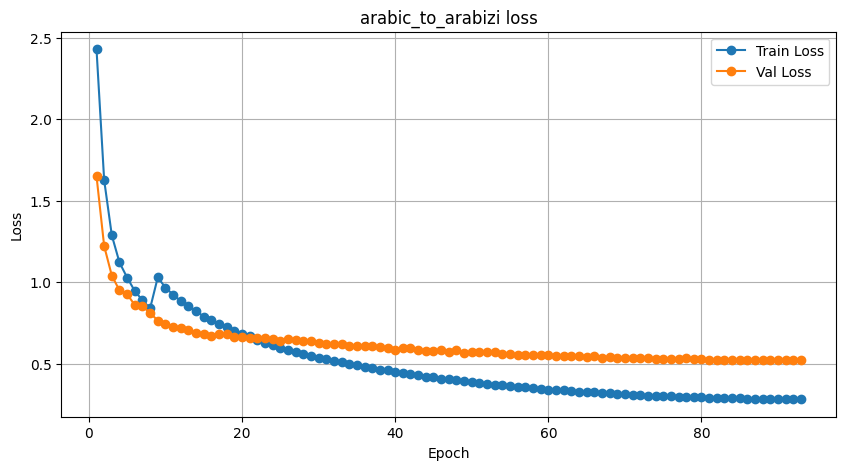

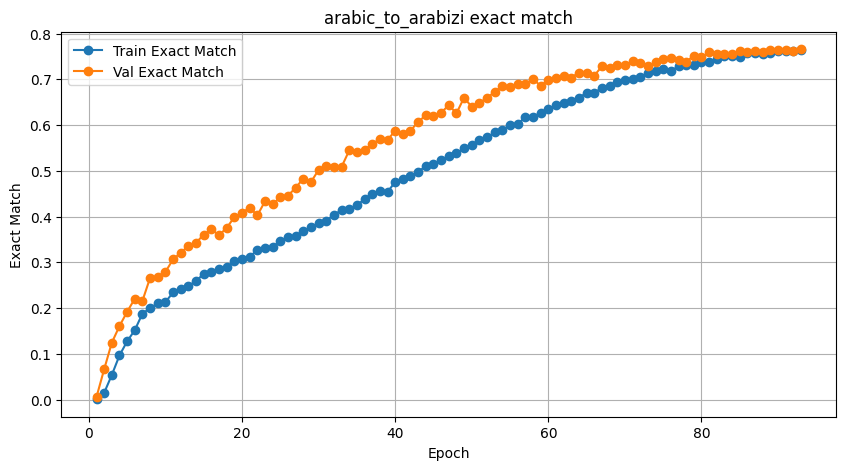

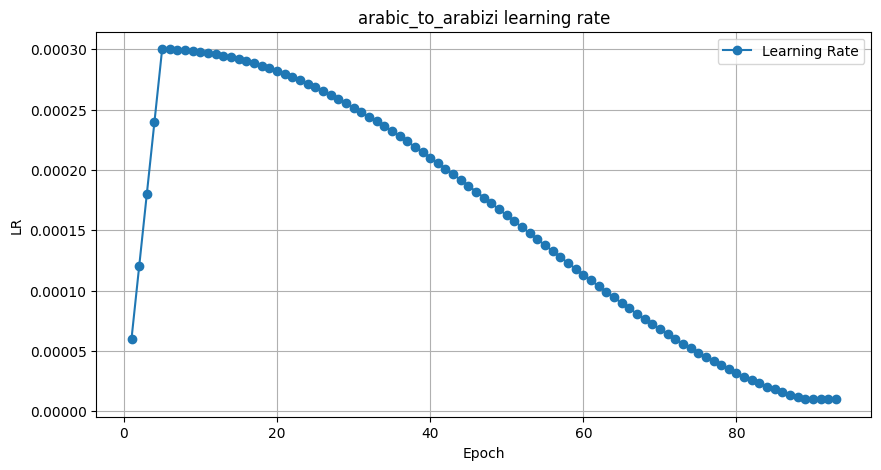

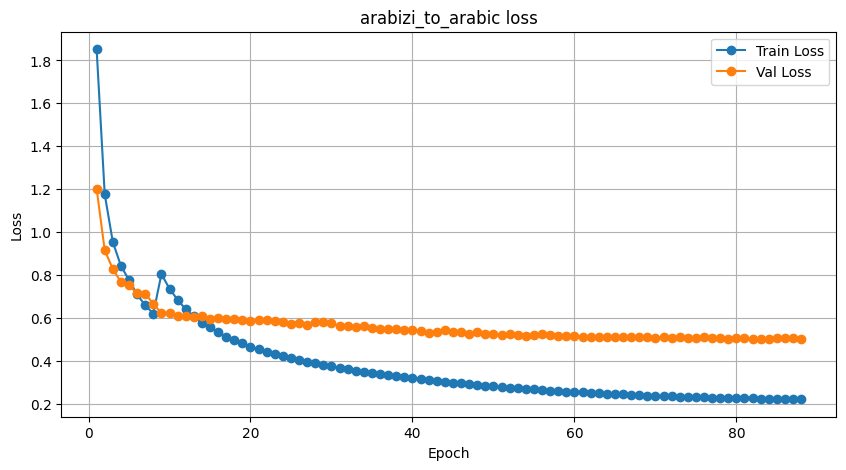

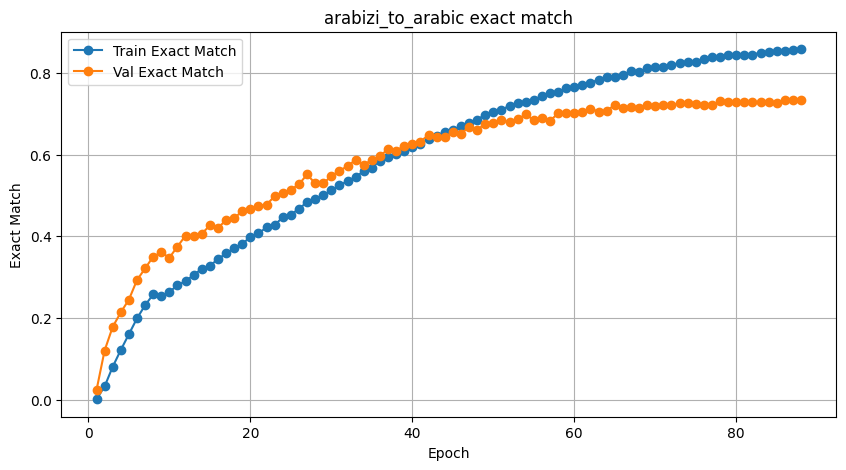

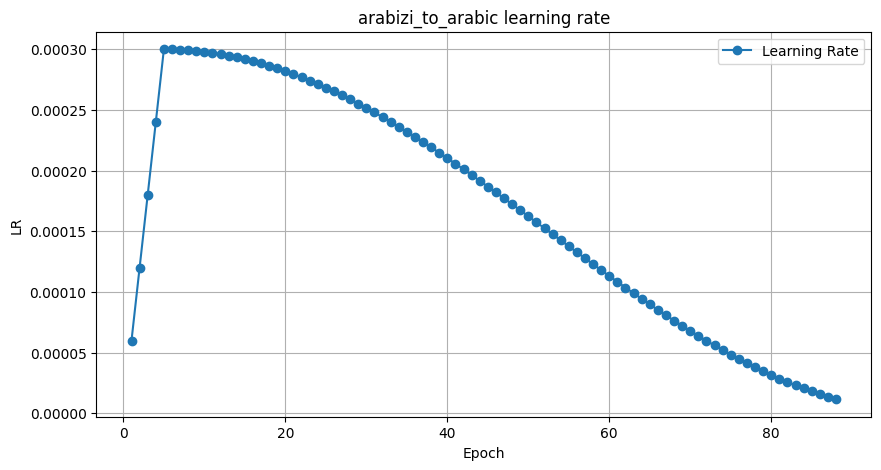

Saved progress snapshot: training_curves_rendered


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:
#################################
# graph training curves
#################################

for task_name in sorted(trained_tasks.keys()):
    task_history = trained_tasks[task_name]["history_df"]

    plt.figure(figsize=(10, 5))
    plt.plot(task_history["epoch"], task_history["train_loss"], marker="o", label="Train Loss")
    plt.plot(task_history["epoch"], task_history["val_loss"], marker="o", label="Val Loss")
    plt.title(f"{task_name} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(task_history["epoch"], task_history["train_exact_match"], marker="o", label="Train Exact Match")
    plt.plot(task_history["epoch"], task_history["val_exact_match"], marker="o", label="Val Exact Match")
    plt.title(f"{task_name} exact match")
    plt.xlabel("Epoch")
    plt.ylabel("Exact Match")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(task_history["epoch"], task_history["lr"], marker="o", label="Learning Rate")
    plt.title(f"{task_name} learning rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.grid(True)
    plt.legend()
    plt.show()

save_stage_snapshot("training_curves_rendered",
    extra_payload={},
    dataframes=None,
)


In [ ]:
#################################
# decoding helpers for inference
#################################


def get_checkpoint_payload_for_direction(direction):
    task_name = get_task_name_for_direction(direction)

    if "trained_tasks" in globals() and task_name in trained_tasks:
        return trained_tasks[task_name]

    if task_name not in task_data:
        raise KeyError(f"Unknown task name for direction {direction}: {task_name}")

    task_paths = get_task_paths(task_name)
    checkpoint_payload = load_checkpoint_payload(task_paths["best_checkpoint"])
    if checkpoint_payload is None:
        checkpoint_payload = load_checkpoint_payload(task_paths["latest_checkpoint"])

    if checkpoint_payload is None:
        raise FileNotFoundError(
            f"No saved checkpoint found on disk for direction '{direction}'. "
            f"Run the training cell or make sure Drive is mounted and the checkpoint exists."
        )

    trained_entry = load_trained_task_from_checkpoint(task_name, task_data[task_name], checkpoint_payload)

    if "trained_tasks" not in globals():
        globals()["trained_tasks"] = {}
    trained_tasks[task_name] = trained_entry
    return trained_entry

def normalize_for_directional_eval(text: str, direction: str):
    if direction == "arabizi_to_arabic":
        normalized = normalize_text(text, lowercase=False)
        if STRIP_DIACRITICS_FOR_ARABIZI_TO_ARABIC_EVAL:
            normalized = strip_arabic_diacritics(normalized)
        return normalized

    if direction == "arabic_to_arabizi":
        return normalize_text(text, lowercase=LOWERCASE_ARABIZI_FOR_EVAL)

    raise ValueError(f"Unknown direction: {direction}")


KNOWN_ARABIC_WORDS = globals().get("KNOWN_ARABIC_WORDS", set())
KNOWN_ARABIZI_WORDS = globals().get("KNOWN_ARABIZI_WORDS", set())


def arabic_lexicon_contains(text: str, direction: str) -> bool:
    known_arabic_words = globals().get("KNOWN_ARABIC_WORDS", KNOWN_ARABIC_WORDS)
    if direction != "arabizi_to_arabic" or not known_arabic_words:
        return False
    return normalize_for_directional_eval(text, direction) in known_arabic_words


def arabizi_lexicon_contains(text: str, direction: str) -> bool:
    known_arabizi_words = globals().get("KNOWN_ARABIZI_WORDS", KNOWN_ARABIZI_WORDS)
    if direction != "arabic_to_arabizi" or not known_arabizi_words:
        return False
    normalized = normalize_text(text, lowercase=LOWERCASE_ARABIZI_FOR_EVAL)
    return normalized in known_arabizi_words


def safe_log1p(value):
    return float(np.log1p(max(float(value), 0.0)))



def safe_ratio(numerator, denominator):
    denominator = float(denominator)
    if abs(denominator) < 1e-8:
        return 0.0
    return float(numerator) / denominator

def count_whitespace_units(text: str) -> int:
    return int(sum(ch.isspace() for ch in str(text)))

def count_vowel_like_arabizi_chars(text: str) -> int:
    text = str(text).lower()
    return int(sum(ch in {"a", "e", "i", "o", "u"} for ch in text))

def build_reranker_feature_vector(source_text, direction, candidate_item):
    candidate_text = candidate_item["text"]
    candidate_score = float(candidate_item.get("score", 0.0))
    candidate_normalized_score = float(candidate_item.get("normalized_score", candidate_score))

    target_frequency_map = DIRECTION_TARGET_FREQUENCY_MAPS.get(direction, {})
    target_frequency = float(target_frequency_map.get(candidate_text, 0.0))

    source_len = float(len(source_text))
    candidate_len = float(len(candidate_text))
    source_digit_count = float(sum(ch.isdigit() for ch in source_text))
    candidate_digit_count = float(sum(ch.isdigit() for ch in candidate_text))
    source_space_count = float(count_whitespace_units(source_text))
    candidate_space_count = float(count_whitespace_units(candidate_text))
    source_vowel_like_count = float(count_vowel_like_arabizi_chars(source_text))
    candidate_vowel_like_count = float(count_vowel_like_arabizi_chars(candidate_text))

    arabic_lex_match = float(
        RERANKER_FEATURE_USE_ARABIC_LEXICON and arabic_lexicon_contains(candidate_text, direction)
    )
    arabizi_lex_match = float(
        RERANKER_FEATURE_USE_ARABIZI_LEXICON and arabizi_lexicon_contains(candidate_text, direction)
    )

    beam_rank = float(candidate_item.get("beam_rank", 0.0))
    score_gap_from_best = float(candidate_item.get("score_gap_from_best", 0.0))
    normalized_score_gap_from_best = float(candidate_item.get("normalized_score_gap_from_best", 0.0))

    return np.array([
        candidate_score,
        candidate_normalized_score,
        source_len,
        candidate_len,
        candidate_len - source_len,
        safe_ratio(candidate_len, source_len),
        source_digit_count,
        candidate_digit_count,
        abs(candidate_digit_count - source_digit_count),
        source_space_count,
        candidate_space_count,
        abs(candidate_space_count - source_space_count),
        source_vowel_like_count,
        candidate_vowel_like_count,
        safe_ratio(candidate_vowel_like_count, source_vowel_like_count),
        arabic_lex_match,
        arabizi_lex_match,
        safe_log1p(target_frequency),
        beam_rank,
        score_gap_from_best,
        normalized_score_gap_from_best,
        float("2" in source_text),
        float("3" in source_text),
        float("5" in source_text),
        float("6" in source_text),
        float("7" in source_text),
        float("8" in source_text),
        float("9" in source_text),
        float("'" in source_text),
        float(" " in source_text),
        float(" " in candidate_text),
    ], dtype=np.float32)


def greedy_decode(model, src_tokens, checkpoint):
    model.eval()

    src_ids = torch.tensor(
        [encode_tokens(src_tokens, checkpoint["src_stoi"], checkpoint["max_src_len"])],
        dtype=torch.long,
        device=DEVICE,
    )

    bos_id = checkpoint["tgt_stoi"][BOS]
    eos_id = checkpoint["tgt_stoi"][EOS]
    generated = [bos_id]

    for _ in range(checkpoint["max_tgt_len"] - 1):
        tgt_input = torch.tensor([generated], dtype=torch.long, device=DEVICE)

        with torch.no_grad():
            logits = model(src_ids, tgt_input)

        next_id = int(logits[0, -1].argmax().item())
        generated.append(next_id)

        if next_id == eos_id:
            break

    pred_tokens = decode_token_ids(generated, checkpoint["tgt_itos"])
    return pred_tokens


def beam_search_decode_nbest(
    model,
    src_tokens,
    checkpoint,
    target_script,
    beam_size=BEAM_SIZE,
    length_penalty=BEAM_LENGTH_PENALTY,
    top_k=RETURN_TOP_K_PREDICTIONS,
):
    model.eval()

    effective_beam_size = max(int(beam_size), int(top_k), 1)

    src_ids = torch.tensor(
        [encode_tokens(src_tokens, checkpoint["src_stoi"], checkpoint["max_src_len"])],
        dtype=torch.long,
        device=DEVICE,
    )

    bos_id = checkpoint["tgt_stoi"][BOS]
    eos_id = checkpoint["tgt_stoi"][EOS]

    def normalized_score(score, seq_len):
        if length_penalty > 0:
            return score / (seq_len ** length_penalty)
        return score

    beams = [([bos_id], 0.0)]

    for _ in range(checkpoint["max_tgt_len"] - 1):
        candidates = []
        all_finished = True

        for seq, score in beams:
            if seq[-1] == eos_id:
                candidates.append((seq, score))
                continue

            all_finished = False
            tgt_input = torch.tensor([seq], dtype=torch.long, device=DEVICE)

            with torch.no_grad():
                logits = model(src_ids, tgt_input)

            log_probs = torch.log_softmax(logits[0, -1], dim=-1)
            top_scores, top_indices = torch.topk(log_probs, k=effective_beam_size)

            for token_score, token_idx in zip(top_scores.tolist(), top_indices.tolist()):
                candidates.append((seq + [int(token_idx)], score + float(token_score)))

        if all_finished:
            break

        candidates = sorted(
            candidates,
            key=lambda item: normalized_score(item[1], len(item[0])),
            reverse=True,
        )
        beams = candidates[:effective_beam_size]

    decoded = []
    seen_text = set()

    final_beams = sorted(
        beams,
        key=lambda item: normalized_score(item[1], len(item[0])),
        reverse=True,
    )

    for seq, score in final_beams:
        pred_tokens = decode_token_ids(seq, checkpoint["tgt_itos"])
        pred_text = detokenize_text(pred_tokens, target_script)
        if pred_text in seen_text:
            continue
        seen_text.add(pred_text)
        decoded.append({
            "text": pred_text,
            "score": float(score),
            "normalized_score": float(normalized_score(score, len(seq))),
            "token_ids": seq,
        })
        if len(decoded) >= top_k:
            break

    if decoded:
        best_raw_score = float(decoded[0]["score"])
        best_normalized_score = float(decoded[0]["normalized_score"])
        for beam_rank, item in enumerate(decoded):
            item["beam_rank"] = int(beam_rank)
            item["score_gap_from_best"] = float(best_raw_score - float(item["score"]))
            item["normalized_score_gap_from_best"] = float(
                best_normalized_score - float(item["normalized_score"])
            )

    return decoded


def get_task_name_for_direction(direction: str) -> str:
    if TRAINING_STRATEGY == "shared":
        return "shared_bidirectional"
    return direction


def tokenize_source_for_inference(text: str, direction: str):
    if direction == "arabizi_to_arabic":
        normalized = normalize_text(text, lowercase=LOWERCASE_ARABIZI)
        source_tokens = tokenize_text_by_script(normalized, "arabizi")
        if TRAINING_STRATEGY == "shared":
            source_tokens = [TO_ARABIC] + source_tokens
        return source_tokens

    if direction == "arabic_to_arabizi":
        normalized = normalize_text(text, lowercase=False)
        source_tokens = tokenize_text_by_script(normalized, "arabic")
        if TRAINING_STRATEGY == "shared":
            source_tokens = [TO_ARABIZI] + source_tokens
        return source_tokens

    raise ValueError(f"Unknown direction: {direction}")


def get_target_script_for_direction(direction: str) -> str:
    if direction == "arabizi_to_arabic":
        return "arabic"
    if direction == "arabic_to_arabizi":
        return "arabizi"
    raise ValueError(f"Unknown direction: {direction}")


def build_reranker_features_for_inference(source_text, direction, candidate_item):
    return build_reranker_feature_vector(
        source_text=source_text,
        direction=direction,
        candidate_item=candidate_item,
    )


def rerank_candidates_with_learned_model(candidate_items, source_text, direction):
    reranker_registry = globals().get("trained_candidate_rerankers", {})
    if direction not in reranker_registry:
        return [dict(item) for item in candidate_items]

    reranker_payload = reranker_registry[direction]
    reranker_model = reranker_payload["model"]
    reranked = [dict(item) for item in candidate_items]

    reranker_model.eval()
    with torch.no_grad():
        for item in reranked:
            features = build_reranker_features_for_inference(source_text, direction, item)
            x = torch.tensor(features, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            learned_score = float(reranker_model(x).item())
            item["learned_reranker_score"] = learned_score
            item["base_normalized_score"] = float(item.get("normalized_score", item.get("score", 0.0)))
            item["adjusted_score"] = learned_score

    reranked = sorted(reranked, key=lambda item: item.get("learned_reranker_score", float("-inf")), reverse=True)
    return reranked


def rerank_candidates_for_direction(candidate_items, direction, source_text=None):
    if not candidate_items:
        return []

    reranked = [dict(item) for item in candidate_items]
    best_base_score = max(item["normalized_score"] for item in reranked)

    for item in reranked:
        item["adjusted_score"] = float(item["normalized_score"])
        item["lexicon_match"] = False

        if direction != "arabizi_to_arabic":
            continue

        item["lexicon_match"] = arabic_lexicon_contains(item["text"], direction)

        if USE_ARABIC_LEXICON_RERANKING and PREFER_LEXICON_MATCH_IN_TOP_K and item["lexicon_match"]:
            item["adjusted_score"] += 999999.0

        if (
            USE_SOFT_LEXICON_RERANKING
            and item["lexicon_match"]
            and (best_base_score - item["normalized_score"]) <= MAX_LEXICON_SCORE_GAP
        ):
            item["adjusted_score"] += SOFT_LEXICON_BONUS

    reranked = sorted(reranked, key=lambda item: item["adjusted_score"], reverse=True)

    if (
        USE_LEARNED_CANDIDATE_RERANKER
        and RERANKER_APPLY_DURING_INFERENCE
        and source_text is not None
        and direction in globals().get("trained_candidate_rerankers", {})
    ):
        reranked = rerank_candidates_with_learned_model(reranked, source_text, direction)

    return reranked


def predict_text_top_k(
    text,
    direction,
    decoder=DEFAULT_DECODER,
    top_k=RETURN_TOP_K_PREDICTIONS,
    return_metadata=False,
):
    task_name = get_task_name_for_direction(direction)
    trained = get_checkpoint_payload_for_direction(direction)
    checkpoint = trained["checkpoint"]
    model = trained["model"]

    source_tokens = tokenize_source_for_inference(text, direction)

    if decoder == "beam":
        beam_candidate_count = max(int(BEAM_SIZE), int(top_k), 1)
        ranked_candidates = beam_search_decode_nbest(
            model,
            source_tokens,
            checkpoint,
            target_script=get_target_script_for_direction(direction),
            beam_size=BEAM_SIZE,
            length_penalty=BEAM_LENGTH_PENALTY,
            top_k=beam_candidate_count,
        )
        ranked_candidates = rerank_candidates_for_direction(ranked_candidates, direction, source_text=text)
        ranked_candidates = ranked_candidates[:top_k]
        return ranked_candidates if return_metadata else [item["text"] for item in ranked_candidates]

    pred_tokens = greedy_decode(model, source_tokens, checkpoint)
    pred_text = detokenize_text(pred_tokens, get_target_script_for_direction(direction))
    fallback = [{
        "text": pred_text,
        "score": 0.0,
        "normalized_score": 0.0,
        "adjusted_score": 0.0,
        "token_ids": None,
        "lexicon_match": arabic_lexicon_contains(pred_text, direction),
        "beam_rank": 0,
        "score_gap_from_best": 0.0,
        "normalized_score_gap_from_best": 0.0,
    }]
    return fallback if return_metadata else [pred_text]


def predict_text(text: str, direction: str, decoder=DEFAULT_DECODER):
    predictions = predict_text_top_k(text, direction, decoder=decoder, top_k=1)
    return predictions[0] if predictions else ""


print(f"Top-k beam evaluation is enabled with k={TOP_K_EVAL_K}.")

save_stage_snapshot("inference_helpers_ready",
    extra_payload={},
    dataframes=None,
)


Top-k beam evaluation is enabled with k=12.
Saved progress snapshot: inference_helpers_ready


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:

#################################
# build or load cached demo lexicons
#################################

# This cell isolates the slow lexicon work so a disconnect costs less.
# The first successful run builds the lexicons and saves them to Drive.
# Later runs load the cached sets directly, which is much faster than rebuilding.

if USE_DRIVE_CACHED_LEXICONS:
    LEXICON_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def load_pickle_if_available(path, default=None):
    path = Path(path)
    if not path.exists():
        return default
    with open(path, "rb") as f:
        return pickle.load(f)

def save_pickle_atomic_for_cache(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    with open(tmp_path, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp_path, path)

def normalize_arabic_token_for_cache(token):
    normalized = normalize_for_directional_eval(token, "arabizi_to_arabic")
    if normalized == "":
        return ""
    if len(normalized) < ARABIC_WORDLIST_MIN_TOKEN_LEN:
        return ""
    return normalized

def normalize_arabizi_token_for_cache(token):
    normalized = normalize_text(token, lowercase=LOWERCASE_ARABIZI_FOR_EVAL)
    if normalized == "":
        return ""
    if len(normalized) < 2:
        return ""
    return normalized

def build_capped_arabizi_lexicon_from_training_data(task_data_dict, max_words):
    # The Arabizi side is built from the notebook's own training targets.
    # We keep the most frequent normalized targets first so the capped demo lexicon stays useful.
    counter = Counter()

    for payload in task_data_dict.values():
        train_df = payload["train_df"]
        if "direction" not in train_df.columns:
            continue

        arabizi_rows = train_df[train_df["direction"] == "arabic_to_arabizi"]
        if len(arabizi_rows) == 0:
            continue

        for text in arabizi_rows["target_text"].dropna().astype(str):
            normalized = normalize_arabizi_token_for_cache(text)
            if normalized != "":
                counter[normalized] += 1

    return {token for token, _ in counter.most_common(max_words)}

def build_internal_arabic_lexicon_with_cap(task_data_dict, max_words):
    # This internal fallback is much smaller than the external wordlist,
    # but it is always available if downloads fail or you explicitly disable them later.
    counter = Counter()

    for payload in task_data_dict.values():
        train_df = payload["train_df"]
        if "direction" not in train_df.columns:
            continue

        arabic_rows = train_df[train_df["direction"] == "arabizi_to_arabic"]
        if len(arabic_rows) == 0:
            continue

        for text in arabic_rows["target_text"].dropna().astype(str):
            normalized = normalize_arabic_token_for_cache(text)
            if normalized != "":
                counter[normalized] += 1

    return {token for token, _ in counter.most_common(max_words)}

def build_capped_external_arabic_lexicon(
    max_words=MAX_KNOWN_ARABIC_WORDS,
    zip_path=ARABIC_WORDLIST_ZIP_PATH,
    extract_dir=ARABIC_WORDLIST_EXTRACT_DIR,
    download_url=ARABIC_WORDLIST_DOWNLOAD_URL,
    force_redownload=ARABIC_WORDLIST_FORCE_REDOWNLOAD,
):
    # The SourceForge Arabic Wordlist is huge and not frequency-ranked.
    # For demo runs we stop once we have a reasonable number of normalized words.
    zip_path = Path(zip_path)
    extract_dir = Path(extract_dir)

    zip_path.parent.mkdir(parents=True, exist_ok=True)

    if force_redownload and zip_path.exists():
        zip_path.unlink()

    if not zip_path.exists():
        print(f"Downloading capped Arabic lexicon source from: {download_url}")
        urllib.request.urlretrieve(download_url, zip_path)

    if extract_dir.exists() and force_redownload:
        shutil.rmtree(extract_dir)

    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    accepted_words = set()
    files_scanned = 0

    arabic_token_pattern = re.compile(r"[\u0621-\u063A\u0641-\u064A\u0660-\u0669]+")
    arabic_only_line_pattern = re.compile(r"^[\u0621-\u063A\u0641-\u064A\u0660-\u0669\s]+$")

    preferred_suffixes = {".txt", ".dic", ".lst", ".csv", ".tsv", ".dat"}
    fallback_suffixes = preferred_suffixes | {".aff", ".xml"}

    file_candidates = [p for p in extract_dir.rglob("*") if p.is_file() and p.suffix.lower() in preferred_suffixes]
    if not file_candidates:
        file_candidates = [p for p in extract_dir.rglob("*") if p.is_file() and p.suffix.lower() in fallback_suffixes]

    for file_path in file_candidates:
        try:
            raw_bytes = file_path.read_bytes()
        except Exception:
            continue

        decoded_text = None
        for encoding in ("utf-8", "utf-16", "cp1256", "latin-1"):
            try:
                decoded_text = raw_bytes.decode(encoding)
                break
            except Exception:
                continue

        if decoded_text is None:
            continue

        files_scanned += 1

        for line in decoded_text.splitlines():
            line = line.strip()
            if not line:
                continue

            if arabic_only_line_pattern.match(line):
                candidate_tokens = line.split()
            else:
                candidate_tokens = arabic_token_pattern.findall(line)

            for token in candidate_tokens:
                normalized = normalize_arabic_token_for_cache(token)
                if normalized == "":
                    continue

                accepted_words.add(normalized)

                if len(accepted_words) >= max_words:
                    metadata = {
                        "source": "arabic_wordlist_capped_for_demo",
                        "downloaded": True,
                        "extracted": True,
                        "files_scanned": files_scanned,
                        "tokens_kept": len(accepted_words),
                        "max_words": max_words,
                    }
                    return accepted_words, metadata

    metadata = {
        "source": "arabic_wordlist_capped_for_demo",
        "downloaded": True,
        "extracted": True,
        "files_scanned": files_scanned,
        "tokens_kept": len(accepted_words),
        "max_words": max_words,
    }
    return accepted_words, metadata

def load_or_build_demo_lexicons():
    if USE_DRIVE_CACHED_LEXICONS and not FORCE_REBUILD_DRIVE_CACHED_LEXICONS:
        cached_arabic = load_pickle_if_available(ARABIC_LEXICON_CACHE_PATH)
        cached_arabizi = load_pickle_if_available(ARABIZI_LEXICON_CACHE_PATH)
        cached_metadata = load_pickle_if_available(LEXICON_CACHE_METADATA_PATH)

        if cached_arabic is not None and cached_arabizi is not None:
            print(f"Loaded cached Arabic lexicon from Drive: {len(cached_arabic):,}")
            print(f"Loaded cached Arabizi lexicon from Drive: {len(cached_arabizi):,}")
            return cached_arabic, cached_arabizi, cached_metadata

    arabizi_lexicon = build_capped_arabizi_lexicon_from_training_data(
        task_data,
        max_words=MAX_KNOWN_ARABIZI_WORDS,
    )

    try:
        arabic_lexicon, arabic_metadata = build_capped_external_arabic_lexicon(
            max_words=MAX_KNOWN_ARABIC_WORDS,
        )
    except Exception as exc:
        print(f"External Arabic lexicon build failed: {type(exc).__name__}: {exc}")
        print("Falling back to a capped internal Arabic lexicon built from the training data.")
        arabic_lexicon = build_internal_arabic_lexicon_with_cap(
            task_data,
            max_words=MAX_KNOWN_ARABIC_WORDS,
        )
        arabic_metadata = {
            "source": "internal_training_lexicon_fallback",
            "downloaded": False,
            "extracted": False,
            "files_scanned": 0,
            "tokens_kept": len(arabic_lexicon),
            "max_words": MAX_KNOWN_ARABIC_WORDS,
        }

    cache_metadata = {
        "arabic": arabic_metadata,
        "arabizi": {
            "source": "training_targets_capped_for_demo",
            "tokens_kept": len(arabizi_lexicon),
            "max_words": MAX_KNOWN_ARABIZI_WORDS,
        },
        "cache_paths": {
            "arabic": str(ARABIC_LEXICON_CACHE_PATH),
            "arabizi": str(ARABIZI_LEXICON_CACHE_PATH),
            "metadata": str(LEXICON_CACHE_METADATA_PATH),
        },
    }

    if USE_DRIVE_CACHED_LEXICONS:
        save_pickle_atomic_for_cache(arabic_lexicon, ARABIC_LEXICON_CACHE_PATH)
        save_pickle_atomic_for_cache(arabizi_lexicon, ARABIZI_LEXICON_CACHE_PATH)
        save_pickle_atomic_for_cache(cache_metadata, LEXICON_CACHE_METADATA_PATH)

    return arabic_lexicon, arabizi_lexicon, cache_metadata

KNOWN_ARABIC_WORDS, KNOWN_ARABIZI_WORDS, LEXICON_CACHE_INFO = load_or_build_demo_lexicons()

print(f"Known Arabic lexicon size available for reranker features: {len(KNOWN_ARABIC_WORDS):,}")
print(f"Known Arabizi lexicon size available for reranker features: {len(KNOWN_ARABIZI_WORDS):,}")
print("Lexicon cache info:")
print(json.dumps(_json_safe(LEXICON_CACHE_INFO), ensure_ascii=False, indent=2))

save_stage_snapshot(
    "demo_lexicons_ready",
    {
        "known_arabic_words": len(KNOWN_ARABIC_WORDS),
        "known_arabizi_words": len(KNOWN_ARABIZI_WORDS),
        "lexicon_cache_info": LEXICON_CACHE_INFO,
    },
)


Loaded cached Arabic lexicon from Drive: 50,000
Loaded cached Arabizi lexicon from Drive: 26,740
Known Arabic lexicon size available for reranker features: 50,000
Known Arabizi lexicon size available for reranker features: 26,740
Lexicon cache info:
{
  "arabic": {
    "source": "arabic_wordlist_capped_for_demo",
    "downloaded": true,
    "extracted": true,
    "files_scanned": 1,
    "tokens_kept": 50000,
    "max_words": 50000
  },
  "arabizi": {
    "source": "training_targets_capped_for_demo",
    "tokens_kept": 26740,
    "max_words": 50000
  },
  "cache_paths": {
    "arabic": "/content/drive/MyDrive/arabizi/_shared_lexicon_cache/known_arabic_words_cap_50000.pkl",
    "arabizi": "/content/drive/MyDrive/arabizi/_shared_lexicon_cache/known_arabizi_words_cap_50000.pkl",
    "metadata": "/content/drive/MyDrive/arabizi/_shared_lexicon_cache/lexicon_cache_metadata_cap_50000.json"
  }
}
Saved progress snapshot: demo_lexicons_ready


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:
#################################
# optional learned candidate reranker
# this stage can be resumed after the base generators are already trained.
# in this v14 notebook, reranker training examples are capped at 5,000 rows
# so you do not rebuild the full 40k-example reranker dataset.
#################################

class CandidateRerankerDataset(Dataset):
    def __init__(self, features, labels, group_ids):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.group_ids = torch.tensor(group_ids, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx], self.group_ids[idx]


class CandidateReranker(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def maybe_limit_reranker_rows(frame, max_rows, seed=SEED):
    if max_rows is None or len(frame) <= max_rows:
        return frame.reset_index(drop=True).copy()
    return frame.sample(max_rows, random_state=seed).reset_index(drop=True)


def build_direction_target_frequency_maps(task_data_dict):
    frequency_maps = {}
    for task_name, payload in task_data_dict.items():
        direction = payload["train_df"]["direction"].iloc[0]
        frequency_maps[direction] = payload["train_df"]["target_text"].value_counts().to_dict()
    return frequency_maps



DIRECTION_TARGET_FREQUENCY_MAPS = build_direction_target_frequency_maps(task_data)

# The cached lexicon cell should usually populate these globals first.
# The defensive fallback below keeps the reranker cell runnable on its own if needed.
if "KNOWN_ARABIZI_WORDS" not in globals() or not globals().get("KNOWN_ARABIZI_WORDS"):
    print("Known Arabizi lexicon was not found in memory; rebuilding a capped training-derived version.")
    KNOWN_ARABIZI_WORDS = build_capped_arabizi_lexicon_from_training_data(
        task_data,
        max_words=MAX_KNOWN_ARABIZI_WORDS,
    )

if "KNOWN_ARABIC_WORDS" not in globals() or not globals().get("KNOWN_ARABIC_WORDS"):
    print("Known Arabic lexicon was not found in memory; rebuilding a capped internal fallback lexicon.")
    KNOWN_ARABIC_WORDS = build_internal_arabic_lexicon_with_cap(
        task_data,
        max_words=MAX_KNOWN_ARABIC_WORDS,
    )

print(f"Known Arabizi lexicon size available for reranker features: {len(KNOWN_ARABIZI_WORDS):,}")
print(f"Known Arabic lexicon size available for reranker features: {len(KNOWN_ARABIC_WORDS):,}")

def build_candidate_feature_vector(source_text, direction, candidate_item):
    return build_reranker_feature_vector(
        source_text=source_text,
        direction=direction,
        candidate_item=candidate_item,
    )


def build_reranker_examples_from_frame(frame, top_k=max(int(RERANKER_TOP_K), int(BEAM_SIZE)), max_rows=None):
    subset = maybe_limit_reranker_rows(frame, max_rows=max_rows)

    feature_rows = []
    labels = []
    group_ids = []
    metadata_rows = []

    for group_idx, (_, row) in enumerate(tqdm(subset.iterrows(), total=len(subset), leave=False)):
        candidate_items = predict_text_top_k(
            row["source_text"],
            row["direction"],
            decoder="beam",
            top_k=top_k,
            return_metadata=True,
        )

        for rank_idx, candidate_item in enumerate(candidate_items):
            features = build_candidate_feature_vector(
                source_text=row["source_text"],
                direction=row["direction"],
                candidate_item=candidate_item,
            )

            if RERANKER_LABEL_POSITIVE_MODE == "strict_exact":
                label = float(candidate_item["text"] == row["target_text"])
            else:
                label = float(
                    normalize_for_directional_eval(candidate_item["text"], row["direction"]) ==
                    normalize_for_directional_eval(row["target_text"], row["direction"])
                )

            feature_rows.append(features)
            labels.append(label)
            group_ids.append(group_idx)
            metadata_rows.append({
                "group_id": group_idx,
                "direction": row["direction"],
                "source_text": row["source_text"],
                "target_text": row["target_text"],
                "candidate_rank": int(candidate_item.get("beam_rank", rank_idx)),
                "candidate_text": candidate_item["text"],
                "candidate_base_score": float(candidate_item.get("normalized_score", candidate_item.get("score", 0.0))),
                "candidate_score_gap_from_best": float(candidate_item.get("normalized_score_gap_from_best", 0.0)),
                "label": label,
            })

    if not feature_rows:
        return None, None, None, pd.DataFrame()

    X = np.stack(feature_rows)
    y = np.array(labels, dtype=np.float32)
    groups = np.array(group_ids, dtype=np.int64)
    metadata_df = pd.DataFrame(metadata_rows)
    return X, y, groups, metadata_df


def reranker_validation_group_accuracy(model, features, labels, group_ids):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(features, dtype=torch.float32, device=DEVICE)
        scores = model(x).detach().cpu().numpy()

    eval_df = pd.DataFrame({
        "group_id": group_ids,
        "label": labels,
        "score": scores,
    })

    wins = 0
    total = 0
    for _, group_df in eval_df.groupby("group_id"):
        if float(group_df["label"].max()) <= 0.0:
            continue
        best_idx = group_df["score"].idxmax()
        wins += int(float(eval_df.loc[best_idx, "label"]) > 0.0)
        total += 1

    if total == 0:
        return 0.0
    return float(wins / total)


def train_candidate_reranker_model(X_train, y_train, groups_train, X_val, y_val, groups_val):
    input_dim = int(X_train.shape[1])
    model = CandidateReranker(input_dim=input_dim, hidden_dim=RERANKER_HIDDEN_DIM).to(DEVICE)

    train_ds = CandidateRerankerDataset(X_train, y_train, groups_train)
    train_loader = DataLoader(
        train_ds,
        batch_size=RERANKER_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=RERANKER_LEARNING_RATE,
        weight_decay=RERANKER_WEIGHT_DECAY,
    )
    criterion = nn.BCEWithLogitsLoss()

    best_state = None
    best_val_loss = float("inf")
    best_val_group_acc = 0.0
    patience_counter = 0
    history_rows = []

    x_val = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32, device=DEVICE)

    for epoch in range(1, RERANKER_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        batches = 0

        for batch_features, batch_labels, _ in train_loader:
            batch_features = batch_features.to(DEVICE)
            batch_labels = batch_labels.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_features)
            loss = criterion(logits, batch_labels)
            loss.backward()
            optimizer.step()

            running_loss += float(loss.item())
            batches += 1

        train_loss = running_loss / max(batches, 1)

        model.eval()
        with torch.no_grad():
            val_logits = model(x_val)
            val_loss = float(criterion(val_logits, y_val_t).item())

        val_group_acc = reranker_validation_group_accuracy(model, X_val, y_val, groups_val)

        history_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_group_accuracy": val_group_acc,
        })

        improved = (val_group_acc > best_val_group_acc + 1e-6) or (
            abs(val_group_acc - best_val_group_acc) <= 1e-6 and val_loss < best_val_loss
        )
        if improved:
            best_val_loss = val_loss
            best_val_group_acc = val_group_acc
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        print(
            f"reranker epoch {epoch}/{RERANKER_EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_group_accuracy={val_group_acc:.4f}"
        )

        if patience_counter >= RERANKER_PATIENCE:
            print("Stopping reranker early due to patience.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history_rows)
    return model, history_df, best_val_loss, best_val_group_acc


def build_direction_reranker_payload(direction):
    task_name = get_task_name_for_direction(direction)
    payload = task_data[task_name]

    train_df = payload["train_df"]
    val_df = payload["val_df"]

    X_train, y_train, groups_train, train_meta = build_reranker_examples_from_frame(
        train_df,
        top_k=max(int(RERANKER_TOP_K), int(BEAM_SIZE)),
        max_rows=RERANKER_TRAIN_MAX_ROWS,
    )
    X_val, y_val, groups_val, val_meta = build_reranker_examples_from_frame(
        val_df,
        top_k=max(int(RERANKER_TOP_K), int(BEAM_SIZE)),
        max_rows=RERANKER_VAL_MAX_ROWS,
    )

    return {
        "direction": direction,
        "X_train": X_train,
        "y_train": y_train,
        "groups_train": groups_train,
        "train_meta": train_meta,
        "X_val": X_val,
        "y_val": y_val,
        "groups_val": groups_val,
        "val_meta": val_meta,
    }


def save_reranker_artifacts(direction, reranker_payload, model, history_df, best_val_loss, best_val_group_acc):
    task_name = get_task_name_for_direction(direction)
    task_paths = get_task_paths(task_name)

    checkpoint_payload = {
        "direction": direction,
        "task_name": task_name,
        "model_state_dict": model.state_dict(),
        "input_dim": int(reranker_payload["X_train"].shape[1]),
        "hidden_dim": int(RERANKER_HIDDEN_DIM),
        "best_val_loss": float(best_val_loss),
        "best_val_group_accuracy": float(best_val_group_acc),
        "train_rows": int(len(reranker_payload["X_train"])),
        "val_rows": int(len(reranker_payload["X_val"])),
        "positive_train_rows": int((reranker_payload["y_train"] > 0).sum()),
        "positive_val_rows": int((reranker_payload["y_val"] > 0).sum()),
        "history": history_df.to_dict(orient="records"),
        "top_k": int(RERANKER_TOP_K),
        "beam_size": int(BEAM_SIZE),
        "feature_names": [
            "candidate_score",
            "candidate_normalized_score",
            "source_len",
            "candidate_len",
            "candidate_len_minus_source_len",
            "candidate_len_ratio_to_source",
            "source_digit_count",
            "candidate_digit_count",
            "abs_digit_count_diff",
            "source_space_count",
            "candidate_space_count",
            "abs_space_count_diff",
            "source_vowel_like_count",
            "candidate_vowel_like_count",
            "candidate_vowel_ratio_to_source",
            "arabic_lex_match",
            "arabizi_lex_match",
            "log_target_frequency",
            "beam_rank",
            "score_gap_from_best",
            "normalized_score_gap_from_best",
            "contains_2",
            "contains_3",
            "contains_5",
            "contains_6",
            "contains_7",
            "contains_8",
            "contains_9",
            "source_has_apostrophe",
            "source_has_space",
            "candidate_has_space",
        ],
    }

    torch.save(checkpoint_payload, task_paths["reranker_checkpoint"])
    history_df.to_csv(task_paths["reranker_history_csv"], index=False)
    save_dataframe_atomic(history_df, task_paths["reranker_history_pkl"])
    save_dataframe_atomic(reranker_payload["train_meta"], task_paths["reranker_train_meta_pkl"])
    save_dataframe_atomic(reranker_payload["val_meta"], task_paths["reranker_val_meta_pkl"])

    write_json_atomic(
        task_paths["training_summary_json"].with_name(task_paths["training_summary_json"].stem + "_reranker.json"),
        {
            "direction": direction,
            "task_name": task_name,
            "best_val_loss": float(best_val_loss),
            "best_val_group_accuracy": float(best_val_group_acc),
            "train_rows": int(len(reranker_payload["X_train"])),
            "val_rows": int(len(reranker_payload["X_val"])),
        },
    )

def load_saved_reranker(direction):
    task_name = get_task_name_for_direction(direction)
    task_paths = get_task_paths(task_name)
    reranker_path = task_paths["reranker_checkpoint"]

    if not reranker_path.exists():
        return None

    checkpoint_payload = torch.load(reranker_path, map_location=DEVICE, weights_only=False)
    model = CandidateReranker(
        input_dim=int(checkpoint_payload["input_dim"]),
        hidden_dim=int(checkpoint_payload.get("hidden_dim", RERANKER_HIDDEN_DIM)),
    ).to(DEVICE)
    model.load_state_dict(checkpoint_payload["model_state_dict"])
    model.eval()

    history_df = pd.DataFrame(checkpoint_payload.get("history", []))

    return {
        "model": model,
        "history_df": history_df,
        "best_val_loss": float(checkpoint_payload.get("best_val_loss", float("inf"))),
        "best_val_group_accuracy": float(checkpoint_payload.get("best_val_group_accuracy", 0.0)),
        "train_rows": int(checkpoint_payload.get("train_rows", 0)),
        "val_rows": int(checkpoint_payload.get("val_rows", 0)),
        "positive_train_rows": int(checkpoint_payload.get("positive_train_rows", 0)),
        "positive_val_rows": int(checkpoint_payload.get("positive_val_rows", 0)),
        "top_k": int(checkpoint_payload.get("top_k", RERANKER_TOP_K)),
    }

trained_candidate_rerankers = {}
reranker_training_summary_rows = []

def reranker_payload_is_usable(reranker_payload, direction):
    required = ["X_train", "y_train", "groups_train", "X_val", "y_val", "groups_val"]
    for key in required:
        if reranker_payload.get(key) is None:
            print(f"Skipping learned reranker for {direction} because {key} is missing.")
            return False

    train_positive_count = int(np.sum(reranker_payload["y_train"] > 0.0))
    val_positive_count = int(np.sum(reranker_payload["y_val"] > 0.0))

    if train_positive_count == 0 or val_positive_count == 0:
        print(
            f"Skipping learned reranker for {direction} because positive labels were absent "
            f"(train={train_positive_count}, val={val_positive_count})."
        )
        return False

    if train_positive_count < RERANKER_MIN_POSITIVES_WARN or val_positive_count < max(10, RERANKER_MIN_POSITIVES_WARN // 10):
        print(
            f"Warning: learned reranker positives are sparse for {direction} "
            f"(train={train_positive_count}, val={val_positive_count})."
        )

    return True

if USE_LEARNED_CANDIDATE_RERANKER:
    for direction in LEARNED_RERANKER_DIRECTIONS:
        print("=" * 80)
        print(f"Building learned reranker for direction: {direction}")

        existing_reranker = load_saved_reranker(direction)
        if existing_reranker is not None:
            print(f"Found saved reranker for {direction}. Loading it from Drive instead of rebuilding.")
            trained_candidate_rerankers[direction] = existing_reranker
            reranker_training_summary_rows.append({
                "direction": direction,
                "train_rows": int(existing_reranker["train_rows"]),
                "val_rows": int(existing_reranker["val_rows"]),
                "positive_train_rows": int(existing_reranker["positive_train_rows"]),
                "positive_val_rows": int(existing_reranker["positive_val_rows"]),
                "best_val_loss": float(existing_reranker["best_val_loss"]),
                "best_val_group_accuracy": float(existing_reranker["best_val_group_accuracy"]),
                "top_k": int(existing_reranker["top_k"]),
            })
            save_stage_snapshot(
                f"{direction}_reranker_loaded_from_checkpoint",
                extra_payload={"direction": direction},
                dataframes=None,
            )
            continue

        try:
            reranker_payload = build_direction_reranker_payload(direction)
            task_name = get_task_name_for_direction(direction)
            task_paths = get_task_paths(task_name)
            save_dataframe_atomic(reranker_payload["train_meta"], task_paths["reranker_train_meta_pkl"])
            save_dataframe_atomic(reranker_payload["val_meta"], task_paths["reranker_val_meta_pkl"])
            save_stage_snapshot(
                f"{direction}_reranker_payload_built",
                extra_payload={
                    "direction": direction,
                    "train_candidate_rows": int(0 if reranker_payload["X_train"] is None else len(reranker_payload["X_train"])),
                    "val_candidate_rows": int(0 if reranker_payload["X_val"] is None else len(reranker_payload["X_val"])),
                },
                dataframes=None,
            )
        except Exception as exc:
            print(f"Skipping learned reranker for {direction} due to build failure: {type(exc).__name__}: {exc}")
            continue

        if not reranker_payload_is_usable(reranker_payload, direction):
            continue

        X_train = reranker_payload["X_train"]
        y_train = reranker_payload["y_train"]
        groups_train = reranker_payload["groups_train"]
        X_val = reranker_payload["X_val"]
        y_val = reranker_payload["y_val"]
        groups_val = reranker_payload["groups_val"]

        positive_train = int((y_train > 0).sum())
        positive_val = int((y_val > 0).sum())
        print(f"Reranker train rows: {len(X_train):,} | positives: {positive_train:,}")
        print(f"Reranker val rows  : {len(X_val):,} | positives: {positive_val:,}")

        try:
            model, history_df, best_val_loss, best_val_group_acc = train_candidate_reranker_model(
                X_train, y_train, groups_train, X_val, y_val, groups_val
            )
        except Exception as exc:
            print(f"Skipping learned reranker for {direction} due to training failure: {type(exc).__name__}: {exc}")
            continue

        save_reranker_artifacts(direction, reranker_payload, model, history_df, best_val_loss, best_val_group_acc)
        save_stage_snapshot(
            f"{direction}_reranker_trained_and_saved",
            extra_payload={
                "direction": direction,
                "best_val_group_accuracy": float(best_val_group_acc),
            },
            dataframes=None,
        )

        trained_candidate_rerankers[direction] = {
            "model": model,
            "history_df": history_df,
            "best_val_loss": float(best_val_loss),
            "best_val_group_accuracy": float(best_val_group_acc),
            "train_rows": int(len(X_train)),
            "val_rows": int(len(X_val)),
            "positive_train_rows": int(positive_train),
            "positive_val_rows": int(positive_val),
            "top_k": int(RERANKER_TOP_K),
        }

        reranker_training_summary_rows.append({
            "direction": direction,
            "train_rows": int(len(X_train)),
            "val_rows": int(len(X_val)),
            "positive_train_rows": int(positive_train),
            "positive_val_rows": int(positive_val),
            "best_val_loss": float(best_val_loss),
            "best_val_group_accuracy": float(best_val_group_acc),
            "top_k": int(RERANKER_TOP_K),
        })
else:
    print("Learned candidate reranker is disabled.")

reranker_training_summary_df = pd.DataFrame(reranker_training_summary_rows)
if len(reranker_training_summary_df):
    display(reranker_training_summary_df)

save_stage_snapshot("reranker_ready",
    extra_payload={"reranker_directions": LEARNED_RERANKER_DIRECTIONS},
    dataframes=['reranker_training_summary_df'],
)


Known Arabizi lexicon size available for reranker features: 26,740
Known Arabic lexicon size available for reranker features: 50,000
Building learned reranker for direction: arabizi_to_arabic
Found saved reranker for arabizi_to_arabic. Loading it from Drive instead of rebuilding.
Saved progress snapshot: arabizi_to_arabic_reranker_loaded_from_checkpoint
Building learned reranker for direction: arabic_to_arabizi


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


Found saved reranker for arabic_to_arabizi. Loading it from Drive instead of rebuilding.
Saved progress snapshot: arabic_to_arabizi_reranker_loaded_from_checkpoint


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


,direction,train_rows,val_rows,positive_train_rows,positive_val_rows,best_val_loss,best_val_group_accuracy,top_k
0,arabizi_to_arabic,99721,19937,21804,3437,0.405581,0.828790,20
1,arabic_to_arabizi,98891,19797,5580,975,0.155760,0.738359,20


Saved progress snapshot: reranker_ready


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:
#################################
# quick sanity checks
#################################

samples = [
    ("arabizi_to_arabic", "2abad"),
    ("arabizi_to_arabic", "mar7aba"),
    ("arabic_to_arabizi", "مَرْحَبًا"),
    ("arabic_to_arabizi", "أَحْمَد"),
]

preview_rows = []
for direction, text in samples:
    preview_rows.append({
        "direction": direction,
        "input": text,
        "prediction_greedy": predict_text(text, direction, decoder="greedy"),
        "prediction_beam": predict_text(text, direction, decoder="beam"),
    })

display(pd.DataFrame(preview_rows))

save_stage_snapshot("sanity_checks_complete",
    extra_payload={},
    dataframes=None,
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


,direction,input,prediction_greedy,prediction_beam
0,arabizi_to_arabic,2abad,اَبَد,اَبَد
1,arabizi_to_arabic,mar7aba,مَرْحَبِة,مَرْحَبِة
2,arabic_to_arabizi,مَرْحَبًا,mar7aab,mar7aab
3,arabic_to_arabizi,أَحْمَد,2a7mad,2a7mad


Saved progress snapshot: sanity_checks_complete


/tmp/ipykernel_2012/145330206.py:182: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_2012/145330206.py:121: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.insert(0, "snapshot_utc", datetime.utcnow().isoformat(timespec="seconds") + "Z")


In [ ]:
#################################
# generated validation and test-set evaluation
#################################


# rebuild combined filtered validation and test frames for generated evaluation
# this keeps evaluation aligned with the post-filter task_data splits used for training/inference


combined_val_df = (
    pd.concat(
        [payload["val_df"] for payload in task_data.values()],
        axis=0,
        ignore_index=True,
    )
    .sort_values(["direction", "source_text", "target_text"])
    .reset_index(drop=True)
)

combined_test_df = (
    pd.concat(
        [payload["test_df"] for payload in task_data.values()],
        axis=0,
        ignore_index=True,
    )
    .sort_values(["direction", "source_text", "target_text"])
    .reset_index(drop=True)
)

print("Rebuilt combined filtered evaluation frames")
print("combined_val_df rows :", len(combined_val_df))
print("combined_test_df rows:", len(combined_test_df))


EXTERNAL_LEXICON_INFO = {
    "source": ARABIC_LEXICON_SOURCE,
    "downloaded": False,
    "extracted": False,
    "files_scanned": 0,
    "tokens_kept": 0,
    "fallback_used": False,
}

ARABIC_TOKEN_PATTERN = re.compile(r"[\u0621-\u063A\u0641-\u064A\u0660-\u0669]+")
ARABIC_ONLY_LINE_PATTERN = re.compile(r"^[\u0621-\u063A\u0641-\u064A\u0660-\u0669\s]+$")

def build_internal_arabic_lexicon():
    if ARABIC_LEXICON_SOURCE == "all_targets":
        source_series = df[arabic_col]
    else:
        source_series = pair_train_df[arabic_col]

    return {
        normalize_for_directional_eval(text, "arabizi_to_arabic")
        for text in source_series.dropna().astype(str)
        if normalize_for_directional_eval(text, "arabizi_to_arabic") != ""
    }

def maybe_download_external_zip(zip_path: Path, url: str, force_redownload: bool = False, source_name: str = "external lexicon"):
    zip_path = Path(zip_path)
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    if zip_path.exists() and not force_redownload:
        print(f"Using existing {source_name} zip at {zip_path}")
        return zip_path

    print(f"Downloading {source_name} from: {url}")
    urllib.request.urlretrieve(url, zip_path)
    EXTERNAL_LEXICON_INFO["downloaded"] = True
    return zip_path

def extract_external_zip(zip_path: Path, extract_dir: Path, force_redownload: bool = False):
    zip_path = Path(zip_path)
    extract_dir = Path(extract_dir)

    if extract_dir.exists() and force_redownload:
        shutil.rmtree(extract_dir)

    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    EXTERNAL_LEXICON_INFO["extracted"] = True
    return extract_dir

def add_normalized_token(token: str, lexicon: set, min_len: int):
    normalized = normalize_for_directional_eval(token, "arabizi_to_arabic")
    if len(normalized) >= min_len:
        lexicon.add(normalized)

def load_arabic_wordlist_lexicon():
    zip_path = maybe_download_external_zip(
        ARABIC_WORDLIST_ZIP_PATH,
        ARABIC_WORDLIST_DOWNLOAD_URL,
        force_redownload=ARABIC_WORDLIST_FORCE_REDOWNLOAD,
        source_name="Arabic Wordlist for Spellchecking",
    )
    extract_dir = extract_external_zip(
        zip_path,
        ARABIC_WORDLIST_EXTRACT_DIR,
        force_redownload=ARABIC_WORDLIST_FORCE_REDOWNLOAD,
    )

    lexicon = set()
    files_scanned = 0

    preferred_suffixes = {".txt", ".dic", ".lst", ".csv", ".tsv", ".dat"}
    fallback_suffixes = preferred_suffixes | {".aff", ".xml"}

    file_candidates = [p for p in extract_dir.rglob("*") if p.is_file() and p.suffix.lower() in preferred_suffixes]
    if not file_candidates:
        file_candidates = [p for p in extract_dir.rglob("*") if p.is_file() and p.suffix.lower() in fallback_suffixes]

    for file_path in file_candidates:
        try:
            raw_bytes = file_path.read_bytes()
        except Exception:
            continue

        decoded_text = None
        for encoding in ("utf-8", "utf-16", "cp1256", "latin-1"):
            try:
                decoded_text = raw_bytes.decode(encoding)
                break
            except Exception:
                continue

        if decoded_text is None:
            continue

        files_scanned += 1

        for line in decoded_text.splitlines():
            line = line.strip()
            if not line:
                continue

            # many wordlists keep one token per line; handle that case first
            if ARABIC_ONLY_LINE_PATTERN.match(line):
                for token in line.split():
                    add_normalized_token(token, lexicon, ARABIC_WORDLIST_MIN_TOKEN_LEN)
                continue

            # fall back to Arabic token extraction if the file has metadata columns
            for token in ARABIC_TOKEN_PATTERN.findall(line):
                add_normalized_token(token, lexicon, ARABIC_WORDLIST_MIN_TOKEN_LEN)

    EXTERNAL_LEXICON_INFO["files_scanned"] = files_scanned
    EXTERNAL_LEXICON_INFO["tokens_kept"] = len(lexicon)

    if not lexicon:
        raise ValueError("Arabic Wordlist parsing finished but produced an empty Arabic lexicon.")

    return lexicon

def load_aracomlex_lexicon():
    zip_path = maybe_download_external_zip(
        ARACOMLEX_ZIP_PATH,
        ARACOMLEX_DOWNLOAD_URL,
        force_redownload=ARACOMLEX_FORCE_REDOWNLOAD,
        source_name="AraComLex",
    )
    extract_dir = extract_external_zip(
        zip_path,
        ARACOMLEX_EXTRACT_DIR,
        force_redownload=ARACOMLEX_FORCE_REDOWNLOAD,
    )

    lexicon = set()
    files_scanned = 0

    for file_path in extract_dir.rglob("*"):
        if not file_path.is_file():
            continue

        suffix = file_path.suffix.lower()
        if suffix in {".png", ".jpg", ".jpeg", ".gif", ".pdf", ".fst", ".far", ".bin", ".exe", ".dll"}:
            continue

        try:
            raw_bytes = file_path.read_bytes()
        except Exception:
            continue

        decoded_text = None
        for encoding in ("utf-8", "utf-16", "cp1256", "latin-1"):
            try:
                decoded_text = raw_bytes.decode(encoding)
                break
            except Exception:
                continue

        if decoded_text is None:
            continue

        files_scanned += 1

        for token in ARABIC_TOKEN_PATTERN.findall(decoded_text):
            add_normalized_token(token, lexicon, ARACOMLEX_MIN_TOKEN_LEN)

    EXTERNAL_LEXICON_INFO["files_scanned"] = files_scanned
    EXTERNAL_LEXICON_INFO["tokens_kept"] = len(lexicon)

    if not lexicon:
        raise ValueError("AraComLex parsing finished but produced an empty Arabic lexicon.")

    return lexicon

def build_known_arabic_lexicon():
    # Prefer the cached demo lexicon when it is already available.
    # This keeps generated evaluation aligned with the reranker features and avoids repeated downloads.
    cached_known_arabic_words = globals().get("KNOWN_ARABIC_WORDS")
    if USE_DRIVE_CACHED_LEXICONS and cached_known_arabic_words:
        EXTERNAL_LEXICON_INFO["source"] = "cached_demo_lexicon"
        EXTERNAL_LEXICON_INFO["tokens_kept"] = len(cached_known_arabic_words)
        cached_metadata = globals().get("LEXICON_CACHE_INFO", {})
        if isinstance(cached_metadata, dict) and "arabic" in cached_metadata:
            EXTERNAL_LEXICON_INFO.update({
                "downloaded": bool(cached_metadata["arabic"].get("downloaded", False)),
                "extracted": bool(cached_metadata["arabic"].get("extracted", False)),
                "files_scanned": int(cached_metadata["arabic"].get("files_scanned", 0)),
                "fallback_used": cached_metadata["arabic"].get("source") == "internal_training_lexicon_fallback",
            })
        return cached_known_arabic_words

    if ARABIC_LEXICON_SOURCE == "arabic_wordlist":
        try:
            return load_arabic_wordlist_lexicon()
        except Exception as exc:
            print(f"Arabic Wordlist lexicon load failed: {type(exc).__name__}: {exc}")
            if not ARABIC_WORDLIST_ALLOW_FALLBACK_TO_INTERNAL:
                raise
            EXTERNAL_LEXICON_INFO["fallback_used"] = True
            print("Falling back to the internal training-derived Arabic lexicon.")
            return build_internal_arabic_lexicon()

    if ARABIC_LEXICON_SOURCE == "aracomlex":
        try:
            return load_aracomlex_lexicon()
        except Exception as exc:
            print(f"AraComLex lexicon load failed: {type(exc).__name__}: {exc}")
            if not ARACOMLEX_ALLOW_FALLBACK_TO_INTERNAL:
                raise
            EXTERNAL_LEXICON_INFO["fallback_used"] = True
            print("Falling back to the internal training-derived Arabic lexicon.")
            return build_internal_arabic_lexicon()

    if ARABIC_LEXICON_SOURCE in {"train_only", "all_targets"}:
        return build_internal_arabic_lexicon()

    raise ValueError(f"Unknown ARABIC_LEXICON_SOURCE: {ARABIC_LEXICON_SOURCE}")

KNOWN_ARABIC_WORDS = build_known_arabic_lexicon()
print(f"Arabic lexicon source: {EXTERNAL_LEXICON_INFO.get('source', ARABIC_LEXICON_SOURCE)}")
print(f"Arabic lexicon size available for reranking: {len(KNOWN_ARABIC_WORDS):,}")
if ARABIC_LEXICON_SOURCE in {"arabic_wordlist", "aracomlex"}:
    print("External lexicon info:", EXTERNAL_LEXICON_INFO)

def maybe_limit_eval_rows(frame, max_rows, seed=SEED):
    subset = frame.copy()
    if max_rows is None or len(subset) <= max_rows:
        return subset.reset_index(drop=True)

    if "direction" not in subset.columns or subset["direction"].nunique() <= 1:
        return subset.sample(n=max_rows, random_state=seed).reset_index(drop=True)

    direction_order = sorted(subset["direction"].unique())
    base_n = max_rows // len(direction_order)
    remainder = max_rows % len(direction_order)

    sampled_parts = []
    for idx, direction in enumerate(direction_order):
        direction_df = subset[subset["direction"] == direction]
        n = base_n + (1 if idx < remainder else 0)
        n = min(len(direction_df), n)
        sampled_parts.append(direction_df.sample(n=n, random_state=seed).copy())

    sampled = pd.concat(sampled_parts, ignore_index=True)
    return sampled.sample(frac=1.0, random_state=seed).reset_index(drop=True)

def choose_lexicon_reranked_prediction(candidate_items, direction):
    if not candidate_items:
        return ""

    reranked = rerank_candidates_for_direction(candidate_items, direction, source_text=None)
    return reranked[0]["text"] if reranked else ""


def evaluate_generated_predictions(
    frame,
    decoder=DEFAULT_DECODER,
    max_rows=MAX_FULL_GENERATION_EVAL_ROWS,
    top_k=TOP_K_EVAL_K,
):
    subset = maybe_limit_eval_rows(frame, max_rows=max_rows)
    beam_metric_ks = sorted({
        int(k) for k in globals().get("BEAM_METRIC_KS", [1, 3, 5, 10])
        if int(k) > 0 and int(k) <= int(top_k)
    })
    if int(top_k) not in beam_metric_ks:
        beam_metric_ks.append(int(top_k))
    beam_metric_ks = sorted(set(beam_metric_ks))

    predictions = []
    top_k_predictions = []
    strict_exact = []
    practical_exact = []
    top_k_strict_exact = []
    top_k_practical_exact = []
    edit_distances = []
    normalized_edit_distances = []
    first_wrong_positions = []
    lexicon_reranked_predictions = []
    lexicon_match_in_top_k = []
    lexicon_reranked_strict_exact = []
    lexicon_reranked_practical_exact = []
    top_prediction_scores = []
    reranked_top_prediction_scores = []

    beam_strict_rank = []
    beam_practical_rank = []
    beam_strict_mrr = []
    beam_practical_mrr = []

    beam_top_k_strict_lists = {k: [] for k in beam_metric_ks}
    beam_top_k_practical_lists = {k: [] for k in beam_metric_ks}

    for _, row in tqdm(subset.iterrows(), total=len(subset)):
        candidate_items = predict_text_top_k(
            row["source_text"],
            row["direction"],
            decoder=decoder,
            top_k=top_k,
            return_metadata=True,
        )
        candidates = [item["text"] for item in candidate_items]

        top_prediction = candidates[0] if candidates else ""

        predictions.append(top_prediction)
        top_k_predictions.append(candidates)
        top_prediction_scores.append(
            float(candidate_items[0].get("adjusted_score", candidate_items[0].get("normalized_score", 0.0)))
            if candidate_items else np.nan
        )

        strict_match = top_prediction == row["target_text"]
        strict_exact.append(strict_match)

        practical_pred = normalize_for_directional_eval(top_prediction, row["direction"])
        practical_tgt = normalize_for_directional_eval(row["target_text"], row["direction"])
        practical_exact.append(practical_pred == practical_tgt)

        candidate_normalized = [normalize_for_directional_eval(candidate, row["direction"]) for candidate in candidates]
        strict_rank = next((idx + 1 for idx, candidate in enumerate(candidates) if candidate == row["target_text"]), np.nan)
        practical_rank = next((idx + 1 for idx, candidate in enumerate(candidate_normalized) if candidate == practical_tgt), np.nan)

        beam_strict_rank.append(strict_rank)
        beam_practical_rank.append(practical_rank)
        beam_strict_mrr.append(0.0 if pd.isna(strict_rank) else 1.0 / float(strict_rank))
        beam_practical_mrr.append(0.0 if pd.isna(practical_rank) else 1.0 / float(practical_rank))

        top_k_strict_exact.append(any(candidate == row["target_text"] for candidate in candidates))
        top_k_practical_exact.append(any(candidate == practical_tgt for candidate in candidate_normalized))

        for k in beam_metric_ks:
            limited_candidates = candidates[:k]
            limited_candidate_normalized = candidate_normalized[:k]
            beam_top_k_strict_lists[k].append(any(candidate == row["target_text"] for candidate in limited_candidates))
            beam_top_k_practical_lists[k].append(any(candidate == practical_tgt for candidate in limited_candidate_normalized))

        dist = levenshtein_distance(top_prediction, row["target_text"])
        edit_distances.append(dist)
        normalized_edit_distances.append(dist / max(len(row["target_text"]), 1))
        first_wrong_positions.append(first_wrong_position(top_prediction, row["target_text"]))

        if row["direction"] == "arabizi_to_arabic":
            lexicon_pred = choose_lexicon_reranked_prediction(candidate_items, row["direction"])
            lexicon_reranked_predictions.append(lexicon_pred)
            lexicon_match = any(item.get("lexicon_match", False) for item in candidate_items)
            lexicon_match_in_top_k.append(lexicon_match)
            lexicon_reranked_strict_exact.append(lexicon_pred == row["target_text"])
            lexicon_reranked_practical_exact.append(
                normalize_for_directional_eval(lexicon_pred, row["direction"]) == practical_tgt
            )
            reranked_items = rerank_candidates_for_direction(candidate_items, row["direction"], source_text=row["source_text"])
            reranked_top_prediction_scores.append(
                float(reranked_items[0].get("adjusted_score", reranked_items[0].get("normalized_score", 0.0)))
                if reranked_items else np.nan
            )
        else:
            lexicon_reranked_predictions.append(None)
            lexicon_match_in_top_k.append(None)
            lexicon_reranked_strict_exact.append(None)
            lexicon_reranked_practical_exact.append(None)
            reranked_top_prediction_scores.append(np.nan)

    subset = subset.copy()
    subset["prediction"] = predictions
    subset["top_k_predictions"] = top_k_predictions
    subset["strict_exact_match"] = strict_exact
    subset["practical_exact_match"] = practical_exact
    subset["top_k_strict_exact_match"] = top_k_strict_exact
    subset["top_k_practical_exact_match"] = top_k_practical_exact
    subset["beam_strict_rank"] = beam_strict_rank
    subset["beam_practical_rank"] = beam_practical_rank
    subset["beam_strict_mrr"] = beam_strict_mrr
    subset["beam_practical_mrr"] = beam_practical_mrr
    subset["edit_distance"] = edit_distances
    subset["normalized_edit_distance"] = normalized_edit_distances
    subset["first_wrong_position"] = first_wrong_positions
    subset["top_prediction_score"] = top_prediction_scores
    subset["lexicon_reranked_prediction"] = lexicon_reranked_predictions
    subset["lexicon_match_in_top_k"] = lexicon_match_in_top_k
    subset["lexicon_reranked_strict_exact_match"] = lexicon_reranked_strict_exact
    subset["lexicon_reranked_practical_exact_match"] = lexicon_reranked_practical_exact
    subset["lexicon_reranked_top_prediction_score"] = reranked_top_prediction_scores
    subset["target_length_bucket"] = subset["target_char_len"].map(length_bucket_label)

    for k in beam_metric_ks:
        subset[f"beam_top_{k}_strict_exact_match"] = beam_top_k_strict_lists[k]
        subset[f"beam_top_{k}_practical_exact_match"] = beam_top_k_practical_lists[k]

    def summarize_eval_frame(frame_to_summarize):
        summary = {
            "rows_evaluated": int(len(frame_to_summarize)),
            "strict_exact_match_pct": float(frame_to_summarize["strict_exact_match"].mean() * 100 if len(frame_to_summarize) else 0.0),
            "practical_exact_match_pct": float(frame_to_summarize["practical_exact_match"].mean() * 100 if len(frame_to_summarize) else 0.0),
            "top_k_strict_exact_match_pct": float(frame_to_summarize["top_k_strict_exact_match"].mean() * 100 if len(frame_to_summarize) else 0.0),
            "top_k_practical_exact_match_pct": float(frame_to_summarize["top_k_practical_exact_match"].mean() * 100 if len(frame_to_summarize) else 0.0),
            "beam_strict_mrr": float(frame_to_summarize["beam_strict_mrr"].mean() if len(frame_to_summarize) else 0.0),
            "beam_practical_mrr": float(frame_to_summarize["beam_practical_mrr"].mean() if len(frame_to_summarize) else 0.0),
            "beam_avg_strict_rank_when_hit": float(frame_to_summarize["beam_strict_rank"].dropna().mean() if frame_to_summarize["beam_strict_rank"].notna().any() else np.nan),
            "beam_avg_practical_rank_when_hit": float(frame_to_summarize["beam_practical_rank"].dropna().mean() if frame_to_summarize["beam_practical_rank"].notna().any() else np.nan),
            "avg_edit_distance": float(frame_to_summarize["edit_distance"].mean() if len(frame_to_summarize) else 0.0),
            "avg_normalized_edit_distance": float(frame_to_summarize["normalized_edit_distance"].mean() if len(frame_to_summarize) else 0.0),
            "decoder": decoder,
            "top_k_used": int(top_k),
        }
        for k in beam_metric_ks:
            summary[f"beam_top_{k}_strict_exact_match_pct"] = float(frame_to_summarize[f"beam_top_{k}_strict_exact_match"].mean() * 100 if len(frame_to_summarize) else 0.0)
            summary[f"beam_top_{k}_practical_exact_match_pct"] = float(frame_to_summarize[f"beam_top_{k}_practical_exact_match"].mean() * 100 if len(frame_to_summarize) else 0.0)
        return summary

    overall_summary = pd.DataFrame([summarize_eval_frame(subset)])

    arabizi_to_arabic_subset = subset[subset["direction"] == "arabizi_to_arabic"].copy()
    if len(arabizi_to_arabic_subset):
        overall_summary["arabizi_to_arabic_lexicon_match_in_top_k_pct"] = float(
            arabizi_to_arabic_subset["lexicon_match_in_top_k"].fillna(False).mean() * 100
        )
        overall_summary["arabizi_to_arabic_lexicon_reranked_practical_exact_match_pct"] = float(
            arabizi_to_arabic_subset["lexicon_reranked_practical_exact_match"].fillna(False).mean() * 100
        )

    direction_rows = []
    for direction_name, direction_frame in subset.groupby("direction"):
        row_summary = summarize_eval_frame(direction_frame)
        row_summary["direction"] = direction_name
        if direction_name == "arabizi_to_arabic":
            row_summary["lexicon_match_in_top_k_pct"] = float(direction_frame["lexicon_match_in_top_k"].fillna(False).mean() * 100)
            row_summary["lexicon_reranked_strict_exact_match_pct"] = float(direction_frame["lexicon_reranked_strict_exact_match"].fillna(False).mean() * 100)
            row_summary["lexicon_reranked_practical_exact_match_pct"] = float(direction_frame["lexicon_reranked_practical_exact_match"].fillna(False).mean() * 100)
        direction_rows.append(row_summary)
    direction_summary = pd.DataFrame(direction_rows)

    length_rows = []
    for (direction_name, bucket_name), bucket_frame in subset.groupby(["direction", "target_length_bucket"]):
        row_summary = summarize_eval_frame(bucket_frame)
        row_summary["direction"] = direction_name
        row_summary["target_length_bucket"] = bucket_name
        length_rows.append(row_summary)
    length_summary = pd.DataFrame(length_rows)

    lexicon_direction_summary = (
        arabizi_to_arabic_subset.groupby("direction")
        .agg(
            rows=("direction", "size"),
            lexicon_match_in_top_k_pct=("lexicon_match_in_top_k", lambda s: float(s.fillna(False).mean() * 100)),
            lexicon_reranked_strict_exact_match_pct=("lexicon_reranked_strict_exact_match", lambda s: float(s.fillna(False).mean() * 100)),
            lexicon_reranked_practical_exact_match_pct=("lexicon_reranked_practical_exact_match", lambda s: float(s.fillna(False).mean() * 100)),
        )
        .reset_index()
        if len(arabizi_to_arabic_subset)
        else pd.DataFrame(columns=[
            "direction",
            "rows",
            "lexicon_match_in_top_k_pct",
            "lexicon_reranked_strict_exact_match_pct",
            "lexicon_reranked_practical_exact_match_pct",
        ])
    )

    return subset, overall_summary, direction_summary, length_summary, lexicon_direction_summary

val_eval_df, val_overall_summary, val_direction_summary, val_length_summary, val_lexicon_direction_summary = evaluate_generated_predictions(
    combined_val_df,
    decoder=DEFAULT_DECODER,
    max_rows=MAX_FULL_GENERATION_EVAL_ROWS,
)
test_eval_df, test_overall_summary, test_direction_summary, test_length_summary, test_lexicon_direction_summary = evaluate_generated_predictions(
    combined_test_df,
    decoder=DEFAULT_DECODER,
    max_rows=MAX_FULL_GENERATION_EVAL_ROWS,
)

print("Validation overall summary")
display(val_overall_summary)
print("Validation direction summary")
display(val_direction_summary)
print("Validation target-length summary")
display(val_length_summary)
print("Validation Arabizi -> Arabic lexicon summary")
display(val_lexicon_direction_summary)

print("Test overall summary")
display(test_overall_summary)
print("Test direction summary")
display(test_direction_summary)
print("Test target-length summary")
display(test_length_summary)
print("Test Arabizi -> Arabic lexicon summary")
display(test_lexicon_direction_summary)

print("Validation sample predictions")
display(val_eval_df.head(20))

print("Test sample predictions")
display(test_eval_df.head(20))

save_stage_snapshot("generated_eval_complete",
    extra_payload={"val_rows": int(len(val_eval_df)), "test_rows": int(len(test_eval_df))},
    dataframes=['val_eval_df', 'test_eval_df'],
)


Rebuilt combined filtered evaluation frames
combined_val_df rows : 6688
combined_test_df rows: 6686
Arabic lexicon source: cached_demo_lexicon
Arabic lexicon size available for reranking: 50,000
External lexicon info: {'source': 'cached_demo_lexicon', 'downloaded': True, 'extracted': True, 'files_scanned': 1, 'tokens_kept': 50000, 'fallback_used': False}


  0%|          | 0/6688 [00:00<?, ?it/s]

/tmp/ipykernel_2012/3969588086.py:451: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  arabizi_to_arabic_subset["lexicon_match_in_top_k"].fillna(False).mean() * 100
/tmp/ipykernel_2012/3969588086.py:454: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  arabizi_to_arabic_subset["lexicon_reranked_practical_exact_match"].fillna(False).mean() * 100
/tmp/ipykernel_2012/3969588086.py:462: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-

  0%|          | 0/6686 [00:00<?, ?it/s]

In [ ]:
#################################
# focused error analysis
#################################

error_df = test_eval_df.copy()
error_df["is_error"] = ~error_df["strict_exact_match"]
error_df["is_top_k_error"] = ~error_df["top_k_practical_exact_match"]
error_df["first_wrong_position_filled"] = error_df["first_wrong_position"].fillna(-1)

direction_error_summary = (
    error_df.groupby("direction")
    .agg(
        rows=("direction", "size"),
        strict_exact_match_pct=("strict_exact_match", lambda s: float(s.mean() * 100)),
        practical_exact_match_pct=("practical_exact_match", lambda s: float(s.mean() * 100)),
        top_k_strict_exact_match_pct=("top_k_strict_exact_match", lambda s: float(s.mean() * 100)),
        top_k_practical_exact_match_pct=("top_k_practical_exact_match", lambda s: float(s.mean() * 100)),
        avg_first_wrong_position=("first_wrong_position_filled", lambda s: float(s[s >= 0].mean()) if (s >= 0).any() else np.nan),
    )
    .reset_index()
)

digit_summary = (
    error_df.groupby(["direction", "contains_digit"])
    .agg(
        rows=("contains_digit", "size"),
        strict_exact_match_pct=("strict_exact_match", lambda s: float(s.mean() * 100)),
        practical_exact_match_pct=("practical_exact_match", lambda s: float(s.mean() * 100)),
        top_k_practical_exact_match_pct=("top_k_practical_exact_match", lambda s: float(s.mean() * 100)),
    )
    .reset_index()
)

digraph_summary = (
    error_df.groupby(["direction", "contains_digraph"])
    .agg(
        rows=("contains_digraph", "size"),
        strict_exact_match_pct=("strict_exact_match", lambda s: float(s.mean() * 100)),
        practical_exact_match_pct=("practical_exact_match", lambda s: float(s.mean() * 100)),
        top_k_practical_exact_match_pct=("top_k_practical_exact_match", lambda s: float(s.mean() * 100)),
    )
    .reset_index()
)

first_wrong_bucket_summary = (
    error_df[error_df["first_wrong_position"].notna()]
    .assign(first_wrong_bucket=lambda x: pd.cut(
        x["first_wrong_position"],
        bins=[-1, 0, 2, 4, 7, 1000],
        labels=["0", "1-2", "3-4", "5-7", "8+"],
    ))
    .groupby(["direction", "first_wrong_bucket"], observed=False)
    .agg(
        rows=("first_wrong_bucket", "size"),
    )
    .reset_index()
)

lexicon_summary = (
    error_df[error_df["direction"] == "arabizi_to_arabic"]
    .groupby("direction")
    .agg(
        rows=("direction", "size"),
        lexicon_match_in_top_k_pct=("lexicon_match_in_top_k", lambda s: float(s.fillna(False).mean() * 100)),
        lexicon_reranked_strict_exact_match_pct=("lexicon_reranked_strict_exact_match", lambda s: float(s.fillna(False).mean() * 100)),
        lexicon_reranked_practical_exact_match_pct=("lexicon_reranked_practical_exact_match", lambda s: float(s.fillna(False).mean() * 100)),
    )
    .reset_index()
)

print("Direction-level error summary")
display(direction_error_summary)

print("Errors broken out by Arabizi digit presence")
display(digit_summary)

print("Errors broken out by Arabizi digraph presence")
display(digraph_summary)

print("Where the first wrong character tends to appear")
display(first_wrong_bucket_summary)

if len(lexicon_summary):
    print("Arabic lexicon reranking summary for Arabizi -> Arabic")
    display(lexicon_summary)

worst_examples = error_df[error_df["is_top_k_error"]].copy()
worst_examples = worst_examples.sort_values(
    ["direction", "normalized_edit_distance", "target_char_len"],
    ascending=[True, False, False],
)

display(worst_examples.head(50)[[
    "direction",
    "source_text",
    "target_text",
    "prediction",
    "top_k_predictions",
    "strict_exact_match",
    "practical_exact_match",
    "top_k_practical_exact_match",
    "lexicon_reranked_prediction",
    "lexicon_reranked_practical_exact_match",
    "edit_distance",
    "normalized_edit_distance",
    "first_wrong_position",
    "contains_digit",
    "contains_digraph",
]])

save_stage_snapshot("error_analysis_complete",
    extra_payload={},
    dataframes=['direction_error_summary'],
)


In [ ]:
#################################
# optional quick decoder comparison on a small validation sample
#################################

comparison_sample = combined_val_df.sample(min(100, len(combined_val_df)), random_state=SEED).copy()

beam_eval_df, beam_overall_summary, _, _, beam_lexicon_direction_summary = evaluate_generated_predictions(
    comparison_sample,
    decoder="beam",
    max_rows=None,
)

greedy_eval_df, greedy_overall_summary, _, _, greedy_lexicon_direction_summary = evaluate_generated_predictions(
    comparison_sample,
    decoder="greedy",
    max_rows=None,
)

decoder_comparison_summary = pd.DataFrame([
    {
        "decoder": "beam",
        "rows_evaluated": int(beam_overall_summary.loc[0, "rows_evaluated"]),
        "strict_exact_match_pct": float(beam_overall_summary.loc[0, "strict_exact_match_pct"]),
        "practical_exact_match_pct": float(beam_overall_summary.loc[0, "practical_exact_match_pct"]),
        "top_k_strict_exact_match_pct": float(beam_overall_summary.loc[0, "top_k_strict_exact_match_pct"]),
        "top_k_practical_exact_match_pct": float(beam_overall_summary.loc[0, "top_k_practical_exact_match_pct"]),
        "avg_edit_distance": float(beam_overall_summary.loc[0, "avg_edit_distance"]),
        "avg_normalized_edit_distance": float(beam_overall_summary.loc[0, "avg_normalized_edit_distance"]),
    },
    {
        "decoder": "greedy",
        "rows_evaluated": int(greedy_overall_summary.loc[0, "rows_evaluated"]),
        "strict_exact_match_pct": float(greedy_overall_summary.loc[0, "strict_exact_match_pct"]),
        "practical_exact_match_pct": float(greedy_overall_summary.loc[0, "practical_exact_match_pct"]),
        "top_k_strict_exact_match_pct": float(greedy_overall_summary.loc[0, "top_k_strict_exact_match_pct"]),
        "top_k_practical_exact_match_pct": float(greedy_overall_summary.loc[0, "top_k_practical_exact_match_pct"]),
        "avg_edit_distance": float(greedy_overall_summary.loc[0, "avg_edit_distance"]),
        "avg_normalized_edit_distance": float(greedy_overall_summary.loc[0, "avg_normalized_edit_distance"]),
    },
])

display(decoder_comparison_summary)

if len(beam_lexicon_direction_summary):
    print("Beam lexicon reranking summary")
    display(beam_lexicon_direction_summary)

if len(greedy_lexicon_direction_summary):
    print("Greedy lexicon reranking summary")
    display(greedy_lexicon_direction_summary)

save_stage_snapshot("decoder_comparison_complete",
    extra_payload={},
    dataframes=['decoder_comparison_summary'],
)


In [ ]:
#################################
# save metadata
#################################

metadata = {
    "experiment_name": EXPERIMENT_NAME,
    "notebook_version": "v14_fresh_drive_beam_metrics",
    "training_strategy": TRAINING_STRATEGY,
    "data_path": str(data_path),
    "arabic_col": arabic_col,
    "arabizi_col": arabizi_col,
    "num_rows_after_cleaning": int(len(df)),
    "pair_train_size": int(len(pair_train_df)),
    "pair_val_size": int(len(pair_val_df)),
    "pair_test_size": int(len(pair_test_df)),
    "task_summary": task_summary_df.to_dict(orient="records"),
    "training_summary": training_summary_df.to_dict(orient="records"),
    "val_generation_overall_summary": val_overall_summary.to_dict(orient="records"),
    "val_generation_direction_summary": val_direction_summary.to_dict(orient="records"),
    "val_generation_length_summary": val_length_summary.to_dict(orient="records"),
    "val_generation_lexicon_direction_summary": val_lexicon_direction_summary.to_dict(orient="records"),
    "test_generation_overall_summary": test_overall_summary.to_dict(orient="records"),
    "test_generation_direction_summary": test_direction_summary.to_dict(orient="records"),
    "test_generation_length_summary": test_length_summary.to_dict(orient="records"),
    "test_generation_lexicon_direction_summary": test_lexicon_direction_summary.to_dict(orient="records"),
    "decoder_comparison_summary": decoder_comparison_summary.to_dict(orient="records"),
    "reranker_training_summary": reranker_training_summary_df.to_dict(orient="records") if "reranker_training_summary_df" in globals() else [],
    "external_lexicon_info": EXTERNAL_LEXICON_INFO,
    "user_config": user_config,
}

if IN_COLAB and output is not None:
    notebook_name = output.eval_js("document.title").replace(" - Colab", "").strip()
    safe_name = re.sub(r"[^\w\-]+", "_", notebook_name).strip("_") or EXPERIMENT_NAME
else:
    safe_name = EXPERIMENT_NAME

json_path = RUN_OUTPUT_DIR / f"{safe_name}.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Saved metadata to {json_path}")
metadata


save_stage_snapshot(
    "metadata_saved",
    extra_payload={"metadata_path": str(json_path)},
    dataframes=None,
)
